# Laboratorio 6 — Análisis de redes sociales (YouTube)

**CC3084 — Data Science | UVG**

Este notebook contiene el desarrollo del laboratorio de análisis de redes sociales usando dos conjuntos de datos de YouTube: `youtube_videos.csv` y `youtube_comments.csv`.

En cada sección se explica primero, en términos sencillos, **qué vamos a hacer y por qué**, y luego se muestra el código y los resultados.

## Preparación del entorno

Antes de analizar los datos, importamos las librerías que vamos a usar (para tablas, gráficas y redes) y definimos una paleta de colores fija —naranja pastel y verde— que se usará en todas las gráficas del laboratorio para mantener un estilo consistente.

In [1]:
import pandas as pd
import numpy as np
import re
import ast
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

# --- Paleta de colores del laboratorio (naranja pastel + verde) ---

COLOR_NARANJA_OSCURO = "#E87C39"
COLOR_NARANJA_CLARO  = "#F09B46"
COLOR_VERDE_OSCURO   = '#1F7A3D'
COLOR_VERDE_CLARO    = '#7CB869'
COLOR_NEUTRO         = '#9A9A93'   

# Orden fijo: así cualquier gráfica que use esta lista mantiene los mismos colores
PALETA_CATEGORICA = [COLOR_NARANJA_OSCURO, COLOR_NARANJA_CLARO, COLOR_VERDE_OSCURO, COLOR_VERDE_CLARO]

# Rampa verde clara->oscura, para mapas de calor y variables de magnitud (no categorías)
CMAP_VERDE_SECUENCIAL = LinearSegmentedColormap.from_list(
    'verde_secuencial',
    ['#EAF6E8', '#C3E6BB', '#9AD48C', '#7CB869', "#548555", "#446850"]
)

sns.set_theme(style='whitegrid', rc={
    'axes.edgecolor': '#4d4d4d',
    'axes.labelcolor': '#2b2b2b',
    'text.color': '#2b2b2b',
    'xtick.color': '#4d4d4d',
    'ytick.color': '#4d4d4d',
    'grid.color': '#e6e6e2',
    'figure.facecolor': '#fcfcfb',
    'axes.facecolor': '#fcfcfb',
})
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10.5

print('Librerías cargadas y paleta de colores lista.')

Librerías cargadas y paleta de colores lista.


## 1. Carga, comprensión e integración de los datos

### 1.1 Carga de los archivos

Tenemos dos archivos: `youtube_videos.csv`, con información de videos y canales (293 videos), y `youtube_comments.csv`, con los comentarios dejados en una parte de esos videos (406 comentarios). El primer paso es abrirlos y revisar que se hayan leído bien.

Al intentar cargarlos con `pd.read_csv` de la forma más simple, Python arrojó un error de formato ("Expected 17 fields, saw 19"). Al revisar el archivo crudo encontramos que los datos fueron exportados con espacios de relleno para alinear las columnas visualmente (por ejemplo, la categoría `topic` queda guardada como `"topic       "`, con espacios extra). Ese relleno provoca que, en algunos comentarios largos, la comilla que abre el texto no quede pegada al inicio del campo, y entonces las comas dentro del comentario se confunden con comas que separan columnas.

La solución fue indicarle al lector de CSV que ignore los espacios que siguen inmediatamente a una coma (`skipinitialspace=True`). Con este ajuste, las 406 filas de comentarios y las 293 filas de videos se leen completas, sin perder ninguna. El relleno de espacios que queda dentro de los valores (nombres, IDs, categorías) se trata a fondo en la sección 2 (limpieza), como pide el enunciado.

In [2]:
# Cargamos ambos archivos indicando skipinitialspace=True para resolver
videos = pd.read_csv('youtube_videos.csv', encoding='utf-8-sig', skipinitialspace=True)
comments = pd.read_csv('youtube_comments.csv', encoding='utf-8-sig', skipinitialspace=True)


videos.columns = videos.columns.str.strip()
comments.columns = comments.columns.str.strip()

print(f'youtube_videos.csv   -> {videos.shape[0]} filas, {videos.shape[1]} columnas')
print(f'youtube_comments.csv -> {comments.shape[0]} filas, {comments.shape[1]} columnas')

youtube_videos.csv   -> 293 filas, 20 columnas
youtube_comments.csv -> 406 filas, 17 columnas


In [3]:
# Primer vistazo a youtube_videos.csv
videos.info()
videos.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   video_id             293 non-null    str  
 1   title                293 non-null    str  
 2   channel_name         293 non-null    str  
 3   channel_id           293 non-null    str  
 4   source_query         293 non-null    str  
 5   source_group         293 non-null    str  
 6   dataset_sources      293 non-null    str  
 7   channel_handle       293 non-null    str  
 8   published_time       280 non-null    str  
 9   view_count_text      280 non-null    str  
 10  description_snippet  268 non-null    str  
 11  video_url            293 non-null    str  
 12  query_hits           293 non-null    str  
 13  keywords             293 non-null    str  
 14  description          267 non-null    str  
 15  view_count           293 non-null    int64
 16  publish_date         293 non-null    

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH pre...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...",El Departamento de Pronóstico de INSIVUMEH pre...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, ...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, ...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado po...,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética ...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado ...",#México #PetróleoMexicano #SoberaníaEnergética...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [4]:
# Primer vistazo a youtube_comments.csv
comments.info()
comments.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           406 non-null    str    
 1   comment_id         406 non-null    str    
 2   video_title        406 non-null    str    
 3   channel_name       406 non-null    str    
 4   channel_id         406 non-null    str    
 5   author_name        406 non-null    str    
 6   author_channel_id  406 non-null    str    
 7   text               406 non-null    str    
 8   source_query       406 non-null    str    
 9   source_group       406 non-null    str    
 10  dataset_sources    406 non-null    str    
 11  author_handle      406 non-null    str    
 12  published_text     406 non-null    str    
 13  like_count_text    217 non-null    float64
 14  reply_count        406 non-null    int64  
 15  is_pinned          406 non-null    str    
 16  viewer_rating      0 non-null      fl

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC ...,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,NaN,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,NaN,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC ...,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4.0,0,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes


**`youtube_videos.csv`**
- **Unidad de observación:** un video publicado en YouTube.
- **Llave primaria:** `video_id` 
- **Variables más relevantes para el laboratorio:**
  - Para identidad/relación: `video_id`, `channel_id` (el canal, más estable que `channel_name`, que sí puede repetirse o cambiar).
  - Para popularidad: `view_count` (numérico, listo para cálculos; `view_count_text` es solo el texto que muestra YouTube).
  - Para clasificación temática: `category`, `source_query`, `source_group`, `keywords`, `query_hits`.
  - Para texto: `title`, `description`.
  - Para tiempo: `publish_date` (fecha real ISO 8601); `published_time` es relativo ("hace 2 días") y depende del momento en que se recolectaron los datos, no lo usaremos como fecha exacta.

**`youtube_comments.csv`**
- **Unidad de observación:** un comentario principal publicado en un video (no incluye respuestas a comentarios).
- **Llave primaria:** `comment_id` (también verificado sin duplicados).
- **Llave foránea:** `video_id`, que conecta cada comentario con su video en `youtube_videos.csv`.
- **Variables más relevantes:**
  - Para identidad del autor: `author_channel_id` (el "DNI" del autor; `author_name` y `author_handle` son solo visibles y pueden repetirse o cambiar).
  - Para contenido: `text` (el comentario en sí).
  - Para popularidad del comentario: `like_count_text` (texto, hay que limpiarlo) y `reply_count` (número de respuestas, **no** identifica quién respondió).
  - Variables que **no aportan nada** en este conjunto: `is_pinned` (siempre `False`) y `viewer_rating` (siempre vacía) — lo confirmamos en la sección 2.

Confirmamos abajo que ambas llaves primarias son únicas (0 duplicados).

In [5]:
# Verificación de llaves primarias
print('Duplicados en video_id (videos):    ', videos['video_id'].duplicated().sum())
print('Duplicados en comment_id (comments):', comments['comment_id'].duplicated().sum())
print()
print('Canales únicos (channel_id) en videos:  ', videos['channel_id'].nunique())
print('Autores únicos (author_channel_id):     ', comments['author_channel_id'].nunique())
print()
print('¿is_pinned siempre False?  ', (comments['is_pinned'] == False).all())
print('¿viewer_rating siempre vacío?', comments['viewer_rating'].isna().all())

Duplicados en video_id (videos):     0
Duplicados en comment_id (comments): 0

Canales únicos (channel_id) en videos:   97
Autores únicos (author_channel_id):      332

¿is_pinned siempre False?   False
¿viewer_rating siempre vacío? True


### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta de búsqueda

El canal es quien publica los videos. Cada video tiene una sola categoría asignada por YouTube (por ejemplo, *News & Politics* o *Education*). Las personas que ven un video pueden dejar un comentario, y cada comentario tiene un autor —que es alguien externo, no el dueño del canal—. Por separado, sabemos con qué consulta de búsqueda se encontró cada video durante la recolección.

Las relaciones, una por una:

- **Canal → Video (1 a N):** un canal (`channel_id`) puede publicar muchos videos, pero cada video pertenece a un solo canal.
- **Video → Comentario (1 a N):** un video puede tener muchos comentarios, pero cada comentario (`comment_id`) pertenece a un solo video (vía `video_id`).
- **Autor → Comentario (1 a N):** un autor (`author_channel_id`) puede escribir varios comentarios, incluso en videos de canales distintos, pero cada comentario tiene un solo autor. El campo `channel_id` dentro de `comments` identifica al canal *comentado*, no a quien comenta.
- **Video → Categoría (N a 1):** cada video tiene exactamente una `category`; varios videos comparten la misma categoría.
- **Video ↔ Consulta de búsqueda (N a M):** un video puede coincidir con varias consultas (`query_hits` es una lista), y una misma consulta (`source_query`) puede traer varios videos. Por eso `source_query`/`source_group` describen cómo se recolectaron los datos, no necesariamente el tema definitivo del video.

Un mismo autor puede comentar en videos de canales distintos — esas coincidencias de audiencia son la base de las redes que se construyen en los ejercicios 4 y 5.

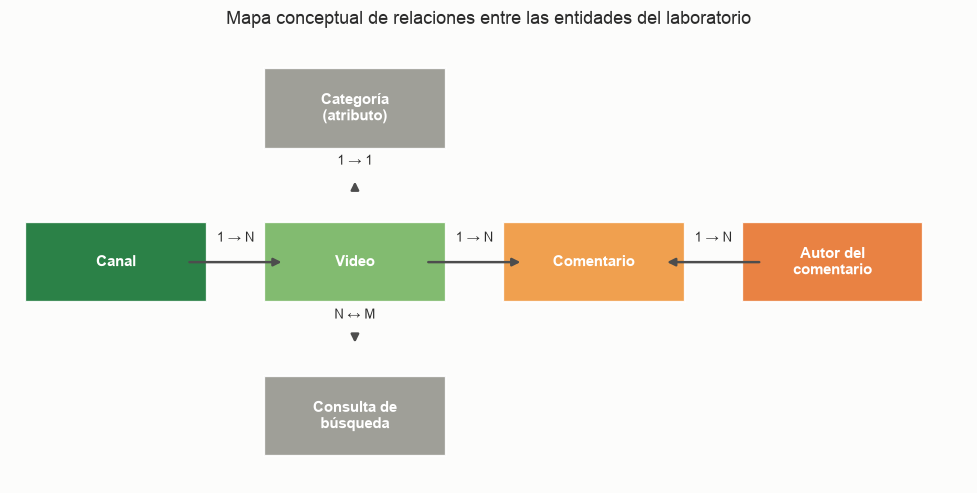

In [6]:
# Esquema conceptual de relaciones 
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

boxes = {
    'Canal':               (1.1, 3, COLOR_VERDE_OSCURO),
    'Video':                (3.6, 3, COLOR_VERDE_CLARO),
    'Comentario':           (6.1, 3, COLOR_NARANJA_CLARO),
    'Autor del\ncomentario': (8.6, 3, COLOR_NARANJA_OSCURO),
    'Categoría\n(atributo)': (3.6, 5.1, COLOR_NEUTRO),
    'Consulta de\nbúsqueda':  (3.6, 0.9, COLOR_NEUTRO),
}

for label, (x, y, color) in boxes.items():
    ax.add_patch(plt.Rectangle((x-0.95, y-0.55), 1.9, 1.1, facecolor=color,
                                edgecolor='white', linewidth=1.5, alpha=0.95, zorder=2))
    ax.text(x, y, label, ha='center', va='center', color='white', fontsize=9.5,
            fontweight='bold', zorder=3)

def arrow(p1, p2, text=''):
    x1, y1, _ = boxes[p1]
    x2, y2, _ = boxes[p2]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#4d4d4d', lw=1.6,
                                 shrinkA=48, shrinkB=48))
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.28, text, ha='center', fontsize=8.5, color='#2b2b2b')

arrow('Canal', 'Video', '1 → N')
arrow('Video', 'Comentario', '1 → N')
arrow('Autor del\ncomentario', 'Comentario', '1 → N')
arrow('Video', 'Categoría\n(atributo)', '1 → 1')
arrow('Video', 'Consulta de\nbúsqueda', 'N ↔ M')

ax.set_title('Mapa conceptual de relaciones entre las entidades del laboratorio',
              fontsize=11.5, color='#2b2b2b', pad=12)
plt.tight_layout()
plt.show()

### 1.4 Integración de los conjuntos mediante `video_id`

Unimos la tabla de comentarios con la tabla de videos usando `video_id` como llave de conexión. Queremos comprobar dos cosas: (1) que todo comentario logre encontrar su video correspondiente, y (2) qué tan repartidos están esos comentarios entre los 293 videos disponibles.

In [7]:
# Integración: unimos comentarios con los metadatos de su video (left join, comments es la base)
# Usamos sufijos para no perder las columnas que existen en ambas tablas con distinto significado
# (channel_name/channel_id/source_query/source_group/dataset_sources)
comments_full = comments.merge(
    videos,
    on='video_id',
    how='left',
    suffixes=('_comment', '_video'),
    indicator=True
)

print('Resultado de la integración (indicator de merge):')
print(comments_full['_merge'].value_counts())
print()

n_match = (comments_full['_merge'] == 'both').sum()
print(f'Comentarios asociados exitosamente a un video: {n_match} de {len(comments)} '
      f'({n_match/len(comments):.1%})')

comments_full = comments_full.drop(columns='_merge')

Resultado de la integración (indicator de merge):
_merge
both          406
left_only       0
right_only      0
Name: count, dtype: int64

Comentarios asociados exitosamente a un video: 406 de 406 (100.0%)


In [8]:
# ¿Cuántos de los 293 videos realmente tienen al menos un comentario en este conjunto?
videos_con_comentarios = comments['video_id'].nunique()
videos_totales = videos['video_id'].nunique()
videos_sin_comentarios = videos_totales - videos_con_comentarios

print(f'Videos con al menos 1 comentario: {videos_con_comentarios} de {videos_totales} '
      f'({videos_con_comentarios/videos_totales:.1%})')
print(f'Videos sin ningún comentario en este conjunto: {videos_sin_comentarios} '
      f'({videos_sin_comentarios/videos_totales:.1%})')

Videos con al menos 1 comentario: 19 de 293 (6.5%)
Videos sin ningún comentario en este conjunto: 274 (93.5%)


**Hallazgos de la integración:**

- El 100% de los 406 comentarios (`_merge == 'both'`) encontró su video correspondiente en `youtube_videos.csv`. No hay comentarios sin video, ni duplicaciones causadas por `video_id` repetidos.
- Solo 19 de los 293 videos (6.5%) tienen al menos un comentario en este conjunto de datos; los otros 274 videos (93.5%) no tienen ningún comentario recolectado. Esto no significa que esos videos no tengan comentarios reales en YouTube — significa que el proceso de recolección solo trajo comentarios para una muestra pequeña y específica de videos. Es una limitación de cobertura que se retoma en la sección 3 (concentración de participación) y en las conclusiones finales.

## 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

Antes de limpiar nada, revisamos el estado real de los datos: cuántos valores faltan, si hay filas repetidas, si alguna columna no varía (y por lo tanto no aporta información), si hay valores extremos, y si los identificadores/nombres/handles son consistentes entre sí. Esto nos dice qué hay que arreglar antes de analizar.

In [9]:
# Dimensiones y tipos de dato
print('videos:  ', videos.shape, '(filas, columnas)')
print('comments:', comments.shape, '(filas, columnas)')
print()
print('Tipos de dato por columna en videos:')
print(videos.dtypes.value_counts())
print()
print('Tipos de dato por columna en comments:')
print(comments.dtypes.value_counts())

videos:   (293, 20) (filas, columnas)
comments: (406, 17) (filas, columnas)

Tipos de dato por columna en videos:
str      19
int64     1
Name: count, dtype: int64

Tipos de dato por columna en comments:
str        14
float64     2
int64       1
Name: count, dtype: int64


In [10]:
# Valores faltantes por columna (solo columnas con al menos 1 faltante)
faltantes_videos = videos.isna().sum()
faltantes_videos = faltantes_videos[faltantes_videos > 0].to_frame('n_faltantes')
faltantes_videos['pct_faltante'] = (faltantes_videos['n_faltantes'] / len(videos) * 100).round(1)
print('Valores faltantes en videos:')
print(faltantes_videos)
print()

faltantes_comments = comments.isna().sum()
faltantes_comments = faltantes_comments[faltantes_comments > 0].to_frame('n_faltantes')
faltantes_comments['pct_faltante'] = (faltantes_comments['n_faltantes'] / len(comments) * 100).round(1)
print('Valores faltantes en comments:')
print(faltantes_comments)

Valores faltantes en videos:
                     n_faltantes  pct_faltante
published_time                13           4.4
view_count_text               13           4.4
description_snippet           25           8.5
description                   26           8.9

Valores faltantes en comments:
                 n_faltantes  pct_faltante
like_count_text          189          46.6
viewer_rating            406         100.0


In [11]:
# Duplicados: filas completas y texto de comentario repetido
print('Filas 100% idénticas en videos:  ', videos.duplicated().sum())
print('Filas 100% idénticas en comments:', comments.duplicated().sum())
print()

dup_texto = comments[comments['text'].duplicated(keep=False)].sort_values('text')
print(f'Comentarios cuyo texto exacto se repite: {len(dup_texto)} filas '
      f'(en {dup_texto["text"].nunique()} textos distintos)')
dup_texto[['comment_id', 'video_id', 'author_channel_id', 'text']]

Filas 100% idénticas en videos:   0
Filas 100% idénticas en comments: 0

Comentarios cuyo texto exacto se repite: 4 filas (en 2 textos distintos)


,comment_id,video_id,author_channel_id,text
116,Ugx8FxDKPAY-M_JhRgd4AaABAg,n8iP75gIpmw,UCi1b_TRQfgO1Z9O2gNGGWNA,Ahora se destapo la CORRUPCION Q EXISTIA Y AHO...
324,Ugz7WPxTOQEwmZpnx_V4AaABAg,n8iP75gIpmw,UCi1b_TRQfgO1Z9O2gNGGWNA,Ahora se destapo la CORRUPCION Q EXISTIA Y AHO...
112,Ugx74OPnWkWaFjpFuA94AaABAg.A7ki-1ED5b2A7nIcG2_svP,n8iP75gIpmw,UCFjudnPLoaSL1BaRuLahyHg,Cierto. ...
272,Ugy__nsWCBggw9EzOUd4AaABAg.A7lbRpGUZoHA7nJxaD37u-,n8iP75gIpmw,UCFjudnPLoaSL1BaRuLahyHg,Cierto. ...


No hay filas 100% duplicadas en ninguna de las dos tablas. Pero sí hay 2 pares de comentarios con el mismo texto exacto, y son de naturaleza distinta:

- Un par (`n8iP75gIpmw`) tiene el mismo autor, mismo video, mismo texto largo, pero `comment_id` distinto, parece un comentario publicado dos veces. 
- El otro par es el texto corto "Cierto.", escrito por dos autores distintos en el mismo video, es solo una coincidencia de lenguaje (una respuesta corta y genérica), no un duplicado real.



In [12]:
# Variables constantes (no varían) y variables redundantes (idénticas a otra columna)
print('--- Columnas constantes en comments ---')
print('is_pinned      -> únicos:', comments['is_pinned'].unique())
print('viewer_rating  -> % vacío:', comments['viewer_rating'].isna().mean() * 100, '%')
print()
print('--- Columnas redundantes en videos (coinciden 100% con otra columna) ---')
print('upload_date == publish_date en el', (videos['upload_date'] == videos['publish_date']).mean() * 100, '% de las filas')
print('owner_handle == channel_handle en el', (videos['owner_handle'] == videos['channel_handle']).mean() * 100, '% de las filas')

--- Columnas constantes en comments ---
is_pinned      -> únicos: <StringArray>
['False    ']
Length: 1, dtype: str
viewer_rating  -> % vacío: 100.0 %

--- Columnas redundantes en videos (coinciden 100% con otra columna) ---
upload_date == publish_date en el 100.0 % de las filas
owner_handle == channel_handle en el 100.0 % de las filas


view_count (videos):
count          293.0
mean        60,430.1
std        515,798.3
min              2.0
25%            215.0
50%          1,175.0
75%          7,465.0
max      8,190,449.0
Name: view_count, dtype: str

reply_count (comments):
count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64



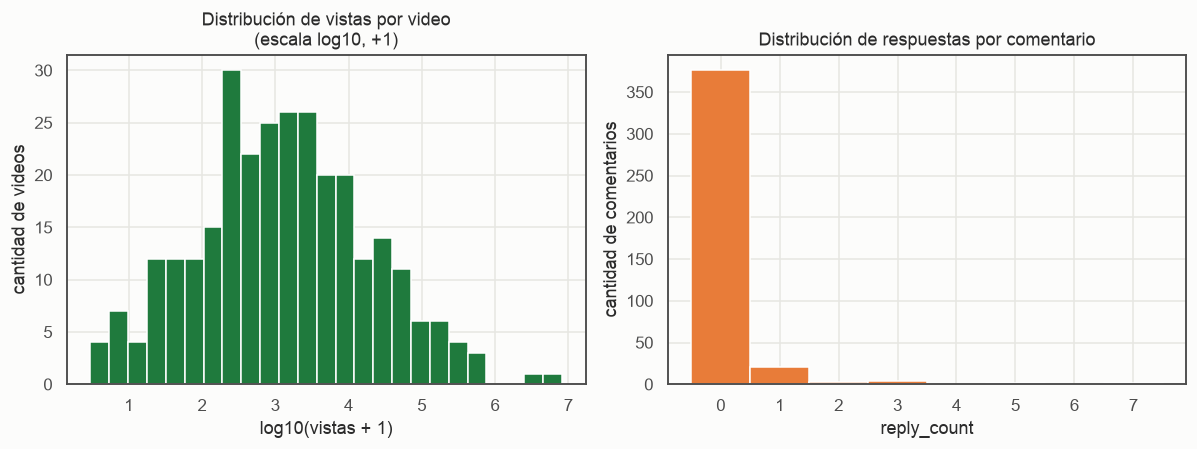

In [13]:
# Valores atípicos: view_count tiene un rango enorme (2 hasta más de 8 millones)
print('view_count (videos):')
print(videos['view_count'].describe().apply(lambda x: f'{x:,.1f}'))
print()
print('reply_count (comments):')
print(comments['reply_count'].describe())
print()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(np.log10(videos['view_count'] + 1), bins=25, color=COLOR_VERDE_OSCURO, edgecolor='white')
axes[0].set_title('Distribución de vistas por video\n(escala log10, +1)')
axes[0].set_xlabel('log10(vistas + 1)')
axes[0].set_ylabel('cantidad de videos')

axes[1].hist(comments['reply_count'], bins=range(0, comments['reply_count'].max() + 2),
             color=COLOR_NARANJA_OSCURO, edgecolor='white', align='left')
axes[1].set_title('Distribución de respuestas por comentario')
axes[1].set_xlabel('reply_count')
axes[1].set_ylabel('cantidad de comentarios')

plt.tight_layout()
plt.show()

In [14]:
# Consistencia entre IDs, nombres y handles
v_strip = videos.assign(**{c: videos[c].str.strip() for c in videos.select_dtypes(include='object').columns})
c_strip = comments.assign(**{c: comments[c].str.strip() for c in comments.select_dtypes(include='object').columns})

n_canales_con_2_nombres = (v_strip.groupby('channel_id')['channel_name'].nunique() > 1).sum()
n_canales_con_2_handles = (v_strip.groupby('channel_id')['channel_handle'].nunique() > 1).sum()
n_autores_con_2_nombres = (c_strip.groupby('author_channel_id')['author_name'].nunique() > 1).sum()

print(f'Canales (channel_id) con más de un channel_name distinto:   {n_canales_con_2_nombres} de {v_strip["channel_id"].nunique()}')
print(f'Canales (channel_id) con más de un channel_handle distinto: {n_canales_con_2_handles} de {v_strip["channel_id"].nunique()}')
print(f'Autores (author_channel_id) con más de un author_name distinto: {n_autores_con_2_nombres} de {c_strip["author_channel_id"].nunique()}')
print()

# ¿El canal_id/nombre del video que aparece en comments coincide con el que aparece en videos?
chequeo = c_strip.merge(v_strip[['video_id', 'channel_id', 'channel_name']], on='video_id', suffixes=('_comment', '_video'))
print('Mismatches de channel_id entre comments y videos (mismo video_id):',
      (chequeo['channel_id_comment'] != chequeo['channel_id_video']).sum())
print()

# Formato de handles: deben iniciar con "/@"
handles_raros = v_strip.loc[~v_strip['channel_handle'].str.startswith('/@'), 'channel_handle']
print('channel_handle con formato inesperado:', len(handles_raros))

# Hallazgo: algunos comment_id contienen un punto, formato típico de una RESPUESTA de YouTube (id_padre.id_respuesta)
es_formato_respuesta = c_strip['comment_id'].str.contains(r'\.', regex=True)
print(f'\ncomment_id con formato de respuesta anidada (contienen "."): {es_formato_respuesta.sum()} de {len(c_strip)} '
      f'({es_formato_respuesta.mean():.1%})')

Canales (channel_id) con más de un channel_name distinto:   0 de 97
Canales (channel_id) con más de un channel_handle distinto: 0 de 97
Autores (author_channel_id) con más de un author_name distinto: 0 de 332

Mismatches de channel_id entre comments y videos (mismo video_id): 0

channel_handle con formato inesperado: 0

comment_id con formato de respuesta anidada (contienen "."): 36 de 406 (8.9%)


**Resumen del diagnóstico:**

- **Dimensiones y tipos:** 293 videos (20 columnas) y 406 comentarios (17 columnas), en su mayoría texto, con algunos numéricos (view_count, reply_count) y fechas en formato texto ISO 8601.
- **Faltantes:** en videos, hasta un 8.9% de descripciones vacías y un 4.4% sin view_count_text/published_time. En comments, el 46.6% de like_count_text está vacío y viewer_rating está vacío al 100%.
- **Duplicados:** ninguna fila 100% repetida, pero sí 2 pares de texto de comentario idéntico (uno probablemente real, otro coincidencia — verarriba).
- **Constantes/redundantes:** is_pinned y viewer_ratin no aportan variabilidad; upload_date/owner_handle son copias exactas de publish_date/channel_handle.
- **Atípicos:** view_count va de 2 a más de 8 millones, una distribución muy asimétrica típica de redes sociales (unos pocos videos "virales" concentran casi todas las vistas). La mayoría de comentarios tiene 0 respuestas; unos pocos llegan hasta 7.
- **Consistencia de identificadores:** cada channel_id tiene siempre el mismo channel_name/channel_handle, y cada author_channel_id tiene siempre el mismo author_name — no encontramos canales o autores con nombres cambiantes en esta muestra. Los handles siguen el formato esperado (/@usuario) en el 100% de los casos, y el canal que aparece en comments siempre coincide con el canal real del video en vdeos.
- **Hallazgo adicional:** aunque el enunciado indica que `youtube_comments.csv` contiene solo comentarios principales, **36 de los 406 registros (8.9%) tienen un comment_id con el formato idPadre.idRespuesta**, que es la estructura típica de una *respuesta* de YouTube, no de un comentario principal. Es decir, una parte de lo que se recolectó como "comentarios" son en realidad respuestas a otro comentario. No los eliminamos (siguen siendo una interacción real autor→video, válida para las redes de los ejercicios 4-5), pero lo documentamos como una inconsistencia de recolección que retomamos en la sección 2.2.

### 2.2 Variables que no pueden usarse o requieren precaución especial

- **`is_pinned` (comments):** siempre `False`. No distingue nada entre comentarios, así que no se usa en ningún análisis.
- **`viewer_rating` (comments):** 100% vacía. Se descarta por completo.
- **`upload_date` y `owner_handle` (videos):** son copias exactas de `publish_date` y `channel_handle`. Se mantienen en la tabla por completitud, pero no se usan como si fueran información independiente (evita contar el mismo dato dos veces).
- **`channel_name` y `author_name` / `*_handle` (ambas tablas):** son visibles y podrían cambiar o repetirse con el tiempo (aunque en esta muestra puntual resultaron consistentes). Se usan solo para mostrar etiquetas en tablas y gráficas; **nunca** como llave para unir, agrupar o construir nodos de red — eso siempre se hace con `channel_id` / `author_channel_id`.
- **`reply_count` (comments):** cuenta cuántas respuestas recibió un comentario, pero no dice quién las escribió. El enunciado es explícito en esto: **no debe interpretarse como una arista entre autores**. Se usa únicamente como una medida de "cuánta conversación generó" ese comentario, nunca para construir relaciones entre personas.
- **`view_count_text` (videos) y `like_count_text` (comments):** son texto, no números. Además, comparamos `view_count_text` contra `view_count` y encontramos que **53 de 280 videos (19%) no coinciden exactamente** entre ambos. Esto tiene sentido: son dos capturas del contador de vistas en momentos distintos del proceso de recolección (las vistas siguen subiendo con el tiempo). Por eso usamos `view_count` como la fuente numérica oficial, y `view_count_text` solo queda como referencia/auditoría, no para cálculos.
- **`query_hits`, `keywords`, `dataset_sources` (videos y/o comments):** están guardadas como texto con forma de lista (por ejemplo `["guatemala lluvias"]`), no como listas reales de Python. Hay que convertirlas antes de poder analizarlas (ver sección 2.3).
- **`comment_id` con formato de respuesta (36 registros):** como se documentó arriba, no son comentarios principales "puros" sino respuestas con un identificador compuesto. Se conservan porque igual representan una interacción autor→video válida, pero se documenta la inconsistencia para no asumir que el 100% de las filas son comentarios de primer nivel.
- **Fechas relativas (`published_time` en videos, `published_text` en comments):** dependen del momento exacto en que se recolectaron los datos ("hace 2 días" hoy no es lo mismo que "hace 2 días" hace un mes). No se usan como fecha exacta; para videos ya existe `publish_date` en formato ISO 8601, que sí es utilizable.

### 2.3 Normalización de identificadores y nombres

Vamos a crear versiones "de trabajo" (`videos_clean` y `comments_clean`) donde:

1. Quitamos los espacios de relleno de **todas** las columnas de texto (incluyendo `video_id`, `channel_id`, `comment_id`, `author_channel_id` — los identificadores también traían espacios extra, como vimos en 1.1).
2. **No** sustituimos ningún ID por su nombre visible: `channel_id`, `video_id`, `comment_id` y `author_channel_id` se mantienen intactos como las llaves oficiales para todo el análisis posterior (uniones, agrupaciones y construcción de redes). `channel_name`/`author_name`/los handles solo se guardan aparte, para usarlos como etiquetas en tablas y gráficas.
3. Convertimos las columnas de tipo "texto con forma de lista" (`query_hits`, `keywords`) a listas reales de Python, usando `ast.literal_eval`, para poder analizarlas más adelante (por ejemplo, contar hashtags o palabras clave).

In [15]:
def parse_lista(valor):
    """Convierte un texto tipo "['a', 'b']" o "[]" en una lista real de Python."""
    if pd.isna(valor):
        return []
    try:
        resultado = ast.literal_eval(valor)
        return resultado if isinstance(resultado, list) else []
    except (ValueError, SyntaxError):
        return []

videos_clean = videos.copy()
comments_clean = comments.copy()

# 1) Quitar espacios de relleno de todas las columnas de texto (incluye los IDs)
for c in videos_clean.select_dtypes(include='object').columns:
    videos_clean[c] = videos_clean[c].str.strip()
for c in comments_clean.select_dtypes(include='object').columns:
    comments_clean[c] = comments_clean[c].str.strip()

# 2) Verificamos que los IDs no perdieron ni ganaron valores únicos al limpiar espacios
assert videos_clean['video_id'].nunique() == videos['video_id'].str.strip().nunique() == 293
assert comments_clean['comment_id'].nunique() == 406
assert videos_clean['channel_id'].nunique() == 97
assert comments_clean['author_channel_id'].nunique() == 332

# 3) Convertimos las columnas de tipo lista (texto) a listas reales
videos_clean['query_hits_lista'] = videos_clean['query_hits'].apply(parse_lista)
videos_clean['keywords_lista'] = videos_clean['keywords'].apply(parse_lista)

print('Ejemplo antes/después de limpiar espacios en source_group:')
print('  crudo:  ', repr(videos['source_group'].iloc[0]))
print('  limpio: ', repr(videos_clean['source_group'].iloc[0]))
print()
print('Ejemplo de keywords convertido de texto a lista real:')
print('  texto original:', videos_clean['keywords'].iloc[0][:80], '...')
print('  lista:         ', videos_clean['keywords_lista'].iloc[0][:5])
print()
print('IDs verificados: los conteos de valores únicos no cambiaron tras la limpieza.')

Ejemplo antes/después de limpiar espacios en source_group:
  crudo:   'topic'
  limpio:  'topic'

Ejemplo de keywords convertido de texto a lista real:
  texto original: ["Canícula prolongada", "Chapin tv", "Fenómeno del Niño", "Guatemala", "Lluvias  ...
  lista:          ['Canícula prolongada', 'Chapin tv', 'Fenómeno del Niño', 'Guatemala', 'Lluvias en Guatemala']

IDs verificados: los conteos de valores únicos no cambiaron tras la limpieza.


### 2.4 Conversión de variables de conteo (texto → número)

- **`view_count_text`** viene como `"2,390 vistas"`. Le quitamos la palabra "vistas", la coma de miles, y lo convertimos a número. No encontramos abreviaturas tipo "1.2K" o "3M" en esta columna (todas las cifras vienen escritas completas), así que el parser solo necesita manejar comas y la palabra "vistas". Como ya existe `view_count` (numérico, capturado en un momento posterior y sin errores de parseo), lo usamos como la cifra oficial; `view_count_text` queda solo de referencia.
- **`like_count_text`** viene sin comas ni abreviaturas, solo dígitos o vacío. Al cargarlo con `skipinitialspace=True`, pandas ya lo reconoce como número (`float64`). Aun así, lo convertimos explícitamente a un entero y documentamos qué hacemos con los vacíos: YouTube no muestra el contador de "me gusta" cuando vale 0, así que **asumimos que un valor vacío equivale a 0 me gusta** — pero dejamos una columna aparte (`like_count_observado`) que marca si el dato realmente venía observado o si lo completamos nosotros, para no perder esa distinción.

In [16]:
def parse_view_count_text(texto):
    """'2,390 vistas' -> 2390 (maneja también abreviaturas K/M si aparecieran)."""
    if pd.isna(texto):
        return np.nan
    m = re.search(r'([\d.,]+)\s*([KkMm]?)', str(texto))
    if not m:
        return np.nan
    numero = float(m.group(1).replace(',', ''))
    sufijo = m.group(2).lower()
    if sufijo == 'k':
        numero *= 1_000
    elif sufijo == 'm':
        numero *= 1_000_000
    return int(round(numero))

videos_clean['view_count_text_parseado'] = videos_clean['view_count_text'].apply(parse_view_count_text)

no_vacios = videos_clean['view_count_text_parseado'].notna()
coincide = (videos_clean.loc[no_vacios, 'view_count_text_parseado'] == videos_clean.loc[no_vacios, 'view_count'])
print(f'view_count_text no vacío: {no_vacios.sum()} de {len(videos_clean)}')
print(f'  de esos, coinciden exactamente con view_count: {coincide.sum()} ({coincide.mean():.1%})')
print(f'  no coinciden (por captura en momentos distintos): {(~coincide).sum()}')
print('  -> usamos "view_count" (ya numérico) como cifra oficial para el resto del laboratorio.')
print()

# like_count: a entero, documentando qué valores fueron observados vs. completados
comments_clean['like_count_observado'] = comments_clean['like_count_text'].notna()
comments_clean['like_count'] = comments_clean['like_count_text'].fillna(0).astype(int)

print('like_count_text observado (no vacío):', comments_clean['like_count_observado'].sum(), 'de', len(comments_clean))
print('like_count (entero, vacíos completados con 0):')
print(comments_clean['like_count'].describe())

view_count_text no vacío: 280 de 293
  de esos, coinciden exactamente con view_count: 227 (81.1%)
  no coinciden (por captura en momentos distintos): 53
  -> usamos "view_count" (ya numérico) como cifra oficial para el resto del laboratorio.

like_count_text observado (no vacío): 217 de 406
like_count (entero, vacíos completados con 0):
count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000
Name: like_count, dtype: float64


### 2.5 Dos versiones del texto: `texto_original` y `texto_limpio`

Guardamos el comentario tal cual llegó en `texto_original` — esa versión no se toca, porque el análisis de sentimiento (sección 9) y cualquier auditoría necesitan el texto real, con mayúsculas, signos de puntuación y emojis incluidos (todo eso aporta información sobre el tono del comentario). La versión `texto_limpio` (que construimos en 2.6) es una simplificación pensada para contar palabras, hashtags y temas — no para medir sentimiento.

In [17]:
comments_clean['texto_original'] = comments_clean['text']

print('Filas con texto_original vacío o solo espacios:',
      (comments_clean['texto_original'].str.strip() == '').sum())
print()
print('Ejemplo de texto_original:')
print(comments_clean['texto_original'].iloc[1])

Filas con texto_original vacío o solo espacios: 0

Ejemplo de texto_original:
Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías que le gusta del otro vando , por ir vestido de mujer se los hubieran ensamblado la maquinaria.


### 2.6 Construcción de `texto_limpio`: decisiones tomadas y por qué

Para pasar de `texto_original` a `texto_limpio` seguimos estos pasos, en este orden, y **antes de borrar cada elemento lo extraemos a su propia columna** para no perder esa señal (URLs, hashtags, menciones y emojis pueden ser útiles más adelante):

1. **Minúsculas:** todo el texto se pasa a minúsculas, para que "Guatemala" y "guatemala" cuenten como la misma palabra.
2. **URLs:** se detectan con una expresión regular y se eliminan del texto (no aportan al conteo de palabras/temas); guardamos si el comentario traía o no un link (`tiene_url`).
3. **Menciones (`@usuario`):** se extraen a una columna aparte (`menciones_encontradas`) y se eliminan del texto — son nombres de usuario, no vocabulario del tema.
4. **Hashtags (`#palabra`):** se extraen a una columna aparte (`hashtags_encontrados`) y, a diferencia de las menciones, la palabra se conserva en el texto (solo se le quita el símbolo `#`), porque un hashtag como "#Guatemala" sí es una palabra con contenido temático.
5. **Emojis:** se extraen a una columna aparte (`emojis_encontrados`, más el conteo `num_emojis`) y se quitan del texto limpio, porque no son palabras que se puedan lematizar o contar como vocabulario — pero se conservan aparte porque son una señal útil de emoción.
6. **Puntuación y números:** se eliminan del texto limpio (dejamos solo letras y espacios, conservando tildes/ñ). Los números casi no aparecen como palabras temáticas relevantes en estos comentarios, así que se descartan para esta versión "para conteo de palabras" — se conservan intactos en `texto_original`.
7. **Stopwords en español:** se eliminan palabras muy frecuentes que no aportan tema (artículos, preposiciones, etc.), usando la lista de español de spaCy.
8. **Lematización:** cada palabra restante se reduce a su forma base (ej. "corriendo" → "correr", "jóvenes" → "joven") usando el modelo en español `es_core_news_sm` de spaCy, para que variantes de una misma palabra se cuenten juntas en las secciones 3 y 7.



In [18]:
import spacy
import emoji

nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@[a-z0-9_.\-]+')
HASHTAG_RE = re.compile(r'#([a-zA-ZÀ-ÿ0-9_]+)')
NO_LETRAS_RE = re.compile(r'[^a-zA-ZáéíóúñüÁÉÍÓÚÑÜ\s]')

def preprocesar_paso1(texto):
    """Minúsculas + extraer y quitar URL/menciones/hashtags/emojis + quitar puntuación y números."""
    t = texto.lower()

    urls = URL_RE.findall(t)
    t = URL_RE.sub(' ', t)

    menciones = MENTION_RE.findall(t)
    t = MENTION_RE.sub(' ', t)

    hashtags = HASHTAG_RE.findall(t)
    t = re.sub(r'#', ' ', t)   # se queda la palabra, se quita solo el símbolo

    emojis_encontrados = [e['emoji'] for e in emoji.emoji_list(t)]
    t = emoji.replace_emoji(t, replace=' ')

    t = NO_LETRAS_RE.sub(' ', t)
    t = re.sub(r'\s+', ' ', t).strip()

    return pd.Series({
        'texto_paso1': t,
        'tiene_url': len(urls) > 0,
        'menciones_encontradas': menciones,
        'hashtags_encontrados': hashtags,
        'emojis_encontrados': emojis_encontrados,
        'num_emojis': len(emojis_encontrados),
    })

paso1 = comments_clean['texto_original'].apply(preprocesar_paso1)
comments_clean = pd.concat([comments_clean, paso1], axis=1)

# Stopwords + lematización con spaCy (se procesan todos los comentarios de una vez, más eficiente)
docs = nlp.pipe(comments_clean['texto_paso1'])
textos_limpios, tokens_limpios = [], []
for doc in docs:
    tokens = [tok.lemma_ for tok in doc if not tok.is_stop and tok.lemma_.strip()]
    tokens_limpios.append(tokens)
    textos_limpios.append(' '.join(tokens))

comments_clean['texto_limpio'] = textos_limpios
comments_clean['tokens_limpios'] = tokens_limpios

print('Listo. Ejemplo de transformación completa:\n')
idx = 1
print('texto_original: ', comments_clean['texto_original'].iloc[idx])
print('texto_paso1:    ', comments_clean['texto_paso1'].iloc[idx])
print('texto_limpio:   ', comments_clean['texto_limpio'].iloc[idx])
print('hashtags:       ', comments_clean['hashtags_encontrados'].iloc[idx])
print('menciones:      ', comments_clean['menciones_encontradas'].iloc[idx])
print('emojis:         ', comments_clean['emojis_encontrados'].iloc[idx])

Listo. Ejemplo de transformación completa:

texto_original:  Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías que le gusta del otro vando , por ir vestido de mujer se los hubieran ensamblado la maquinaria.
texto_paso1:     están jóvenes porque no buscan un trabajo tuvieron suerte que no hay policías que le gusta del otro vando por ir vestido de mujer se los hubieran ensamblado la maquinaria
texto_limpio:    joven buscar trabajo tener suerte policía gustar var vestir mujer haber ensamblar maquinaria
hashtags:        []
menciones:       []
emojis:          []


In [19]:
# Más ejemplos de antes/después, priorizando comentarios que sí tenían hashtags, menciones o emojis
interesantes = comments_clean[
    (comments_clean['num_emojis'] > 0) |
    (comments_clean['hashtags_encontrados'].str.len() > 0) |
    (comments_clean['menciones_encontradas'].str.len() > 0)
].head(4)

for _, fila in interesantes.iterrows():
    print('ORIGINAL:', fila['texto_original'][:140])
    print('LIMPIO:  ', fila['texto_limpio'])
    print('-' * 100)

ORIGINAL: Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳
LIMPIO:   vivo guatemala
----------------------------------------------------------------------------------------------------
ORIGINAL: Otro pequeño truco es que tenés un plan mensual de Gb y redes ilimitadas y luego te mandan mensaje que consumiste el 95% de tu plan y ahi vi
LIMPIO:   pequeño truco tenés plan mensual gb red ilimitado mandan mensaje consumistir plan venir caos verifica consumo dato haber utilizar red mínimo internet ende recarga adicional ir averiguar consumistir dato recargar negoció redondo ambos empresa
----------------------------------------------------------------------------------------------------
ORIGINAL: Qué lujooo de contenidooooo 🔥
LIMPIO:   lujooo contenidooooo
----------------------------------------------------------------------------------------------------
ORIGINAL: Entoces las mismas 💩😡 Junta Directiva haciéndose de las suyas con el dinero del Estado. Ya basta de tanto robo, barriles sin fondos..💩😡
LIMPIO:   entoz j

### 2.7 Efecto cuantificado de la limpieza

No eliminamos ningún comentario durante la limpieza de texto (seguimos teniendo 406 filas); lo que cambia es el contenido de la columna de texto. Medimos: cuántos comentarios quedaron vacíos después de limpiar, cuánto se redujo el texto en promedio, y cómo cambió la cantidad de duplicados.

In [20]:
# Registros modificados por la limpieza
n_total = len(comments_clean)
n_modificados = (comments_clean['texto_original'].str.lower().str.strip() != comments_clean['texto_limpio']).sum()
print(f'Comentarios modificados por la limpieza: {n_modificados} de {n_total} ({n_modificados/n_total:.1%})')
print()

# Textos vacíos: antes vs. después
vacios_antes = (comments_clean['texto_original'].str.strip() == '').sum()
vacios_despues = (comments_clean['texto_limpio'].str.strip() == '').sum()
print(f'Textos vacíos ANTES de limpiar:   {vacios_antes}')
print(f'Textos vacíos DESPUÉS de limpiar: {vacios_despues}')
if vacios_despues > 0:
    print('\nComentarios que quedaron vacíos tras la limpieza (probablemente solo tenían emojis, URL o menciones):')
    print(comments_clean.loc[comments_clean['texto_limpio'].str.strip() == '', 'texto_original'].tolist())
print()

# Duplicados: antes (texto original) vs. después (texto limpio)
dup_antes = comments_clean['texto_original'].duplicated().sum()
dup_despues = comments_clean['texto_limpio'].duplicated().sum()
print(f'Comentarios con texto duplicado ANTES de limpiar (texto_original):   {dup_antes}')
print(f'Comentarios con texto duplicado DESPUÉS de limpiar (texto_limpio):   {dup_despues}')
print(f'  -> la limpieza generó {dup_despues - dup_antes} duplicados nuevos '
      f'(comentarios que antes eran distintos y ahora se ven iguales tras quitar mayúsculas/puntuación/emojis).')
print()

# Reducción de longitud promedio
comments_clean['longitud_original'] = comments_clean['texto_original'].str.len()
comments_clean['longitud_limpia'] = comments_clean['texto_limpio'].str.len()
reduccion_pct = 1 - (comments_clean['longitud_limpia'].sum() / comments_clean['longitud_original'].sum())
print(f'Longitud total de caracteres: {comments_clean["longitud_original"].sum():,} -> '
      f'{comments_clean["longitud_limpia"].sum():,} (reducción del {reduccion_pct:.1%})')

Comentarios modificados por la limpieza: 397 de 406 (97.8%)

Textos vacíos ANTES de limpiar:   0
Textos vacíos DESPUÉS de limpiar: 8

Comentarios que quedaron vacíos tras la limpieza (probablemente solo tenían emojis, URL o menciones):
['😮', '❤🎉', 'que?', 'Cierto.', '😂😂', '\u200b\xa0@Murmullodelbarrio\xa0👍🇬🇹', '👏👏👏👏👏👏', 'Cierto.']

Comentarios con texto duplicado ANTES de limpiar (texto_original):   2
Comentarios con texto duplicado DESPUÉS de limpiar (texto_limpio):   12
  -> la limpieza generó 10 duplicados nuevos (comentarios que antes eran distintos y ahora se ven iguales tras quitar mayúsculas/puntuación/emojis).

Longitud total de caracteres: 83,807 -> 31,049 (reducción del 63.0%)


Lectura de los resultados: la limpieza modificó el texto del 97.8% de los comentarios (397 de 406) — es lo esperado, ya que casi todo comentario tiene al menos una mayúscula o un signo de puntuación.

8 comentarios quedaron vacíos tras la limpieza. Al revisarlos, son casos como "😮", "❤🎉", "que?" o "Cierto." — mensajes que originalmente ya eran solo emojis o palabras que spaCy clasifica como palabras vacías de contenido. Esto no es un error, es información real: esos comentarios expresan una reacción breve más que un tema. Por eso no los eliminamos de la tabla — siguen siendo interacciones autor-video válidas y su sentimiento se puede seguir evaluando desde el texto original (sección 9); simplemente no aportan palabras a los análisis de frecuencia/temas de la sección 3.

Los duplicados de texto pasaron de 2 a 12 al comparar el texto limpio en lugar del original. Tiene sentido: mensajes cortos como "Cierto." o reacciones de un par de emojis, escritos por autores distintos, se vuelven idénticos una vez que se les quita mayúsculas, puntuación y emojis. Este aumento de duplicados no indica más contenido repetido real, sino que la limpieza vuelve más gruesa la comparación.

El texto se redujo 63% en cantidad de caracteres en promedio, principalmente por quitar URLs, menciones, puntuación y palabras vacías — es una simplificación fuerte pero intencional, pensada solo para contar palabras y temas, no para leer los comentarios como tal (para eso siempre queda el texto original).

## 3. Análisis exploratorio

### 3.1 Descripción general

Con los datos ya limpios, describimos el panorama general: cuántos videos, canales, comentarios y autores hay, cómo se reparten los videos entre canales, cuántos comentarios y autores distintos tiene cada video, y cómo lucen las visualizaciones, respuestas, me gusta, categorías, consultas de búsqueda, hashtags, palabras y bigramas.

In [21]:
# Conteos básicos
print('Videos:    ', videos_clean['video_id'].nunique())
print('Canales:   ', videos_clean['channel_id'].nunique())
print('Comentarios:', comments_clean['comment_id'].nunique())
print('Autores:   ', comments_clean['author_channel_id'].nunique())

Videos:     293
Canales:    97
Comentarios: 406
Autores:    332


count    97.000000
mean      3.020619
std       5.141699
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      32.000000
Name: video_id, dtype: float64



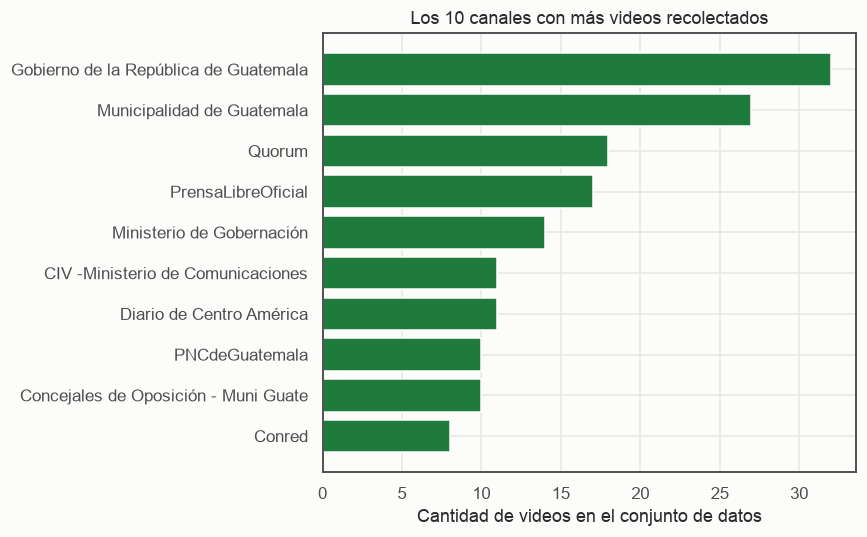

In [22]:
# Videos por canal: la mayoría de canales aportó muy pocos videos, y unos cuantos aportaron muchos
videos_por_canal = videos_clean.groupby(['channel_id', 'channel_name'])['video_id'].nunique().sort_values(ascending=False)
print(videos_por_canal.describe())
print()

top10_canales = videos_por_canal.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
etiquetas = [n for _, n in top10_canales.index]
ax.barh(etiquetas[::-1], top10_canales.values[::-1], color=COLOR_VERDE_OSCURO)
ax.set_xlabel('Cantidad de videos en el conjunto de datos')
ax.set_title('Los 10 canales con más videos recolectados')
plt.tight_layout()
plt.show()

In [23]:
# Comentarios y autores únicos por video (solo tiene sentido calcularlo para los 19 videos con comentarios)
comentarios_por_video = comments_clean.groupby('video_id').agg(
    n_comentarios=('comment_id', 'nunique'),
    n_autores=('author_channel_id', 'nunique'),
)
comentarios_por_video = comentarios_por_video.merge(
    videos_clean[['video_id', 'title', 'channel_name', 'view_count', 'category']],
    on='video_id',
).sort_values('n_comentarios', ascending=False)

comentarios_por_video[['title', 'channel_name', 'category', 'view_count', 'n_comentarios', 'n_autores']]

,title,channel_name,category,view_count,n_comentarios,n_autores
14,Qué rico come tu diputado,Quorum,News & Politics,11775,161,128
12,La cooptación de Walter Mazariegos en la USAC,Quorum,News & Politics,10156,50,49
2,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,Entertainment,11670,45,32
4,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,News & Politics,14200,25,18
5,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,Entertainment,3628,25,19
13,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,News & Politics,304089,25,25
17,Arroz con pollo a la MONOPOLIO,Quorum,News & Politics,1954,16,16
0,Capturan a presuntos delincuentes disfrazados ...,Noti7,News & Politics,6692,14,13
15,Internet: escoger el menos malo,Quorum,News & Politics,717,12,10
10,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,News & Politics,5469,7,7


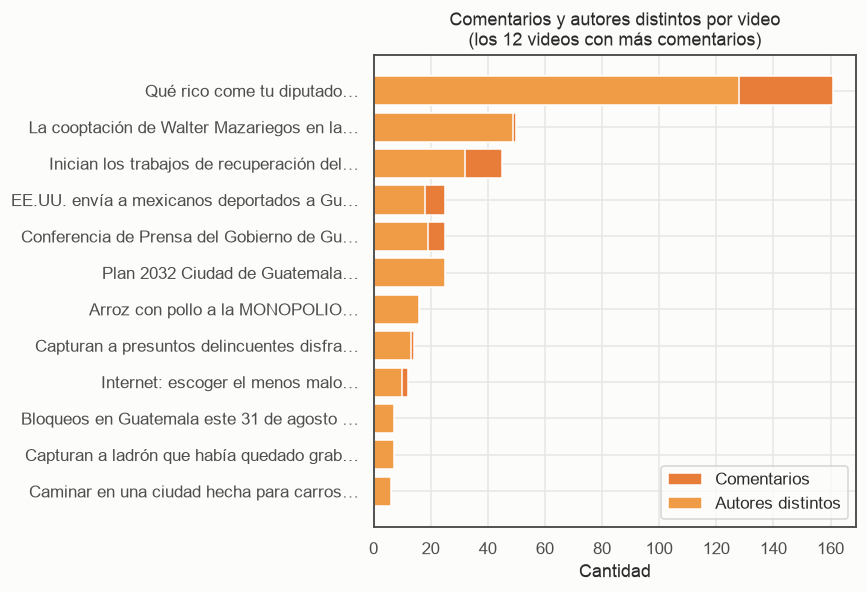

In [24]:
fig, ax = plt.subplots(figsize=(8, 5.5))
top_videos = comentarios_por_video.head(12)
titulos_cortos = top_videos['title'].str.slice(0, 40) + '…'
ax.barh(titulos_cortos[::-1], top_videos['n_comentarios'][::-1], color=COLOR_NARANJA_OSCURO, label='Comentarios')
ax.barh(titulos_cortos[::-1], top_videos['n_autores'][::-1], color=COLOR_NARANJA_CLARO, label='Autores distintos')
ax.set_xlabel('Cantidad')
ax.set_title('Comentarios y autores distintos por video\n(los 12 videos con más comentarios)')
ax.legend()
plt.tight_layout()
plt.show()

Recordando lo que ya vimos en la sección 1: de los 293 videos, solo 19 tienen algún comentario en este conjunto de datos. Un solo video, "Qué rico come tu diputado" del canal Quorum, concentra 161 de los 406 comentarios (el 40% de todos los comentarios de todo el conjunto) y 128 autores distintos. Le sigue "La cooptación de Walter Mazariegos en la USAC", también de Quorum, con 50 comentarios. El resto de videos con comentarios tiene cantidades mucho más modestas.

In [25]:
# Visualizaciones (view_count), respuestas (reply_count) y me gusta (like_count)
print('Visualizaciones por video (los 293):')
print(videos_clean['view_count'].describe().apply(lambda x: f'{x:,.0f}'))
print()
print('Respuestas por comentario (reply_count):')
print(comments_clean['reply_count'].describe())
print()
print('Me gusta por comentario (like_count):')
print(comments_clean['like_count'].describe())
print()

top5_likes = comments_clean.sort_values('like_count', ascending=False).head(5)
print('Los 5 comentarios con más me gusta, todos del mismo video ("Plan 2032 Ciudad de Guatemala"):')
top5_likes[['author_name', 'like_count', 'reply_count', 'texto_original']]

Visualizaciones por video (los 293):
count          293
mean        60,430
std        515,798
min              2
25%            215
50%          1,175
75%          7,465
max      8,190,449
Name: view_count, dtype: str

Respuestas por comentario (reply_count):
count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64

Me gusta por comentario (like_count):
count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000
Name: like_count, dtype: float64



Los 5 comentarios con más me gusta, todos del mismo video ("Plan 2032 Ciudad de Guatemala"):


,author_name,like_count,reply_count,texto_original
299,@zetag,405,3,Quiero vivir en esa Guatemala :v
193,@elenaluarca9377,329,5,Que bueno que Guatemala sea una cuidad bonita ...
338,@samuelaguilar529,211,3,Me encantaría vivir por un tiempo en Guatemala...
124,@TheAlexX_C,191,2,"Que bella es la Ciudad de Guatemala, unica en ..."
184,@sabinamarinaguerra3248,113,1,Se ve moderna Y bella la ciudad de Guatemala ....


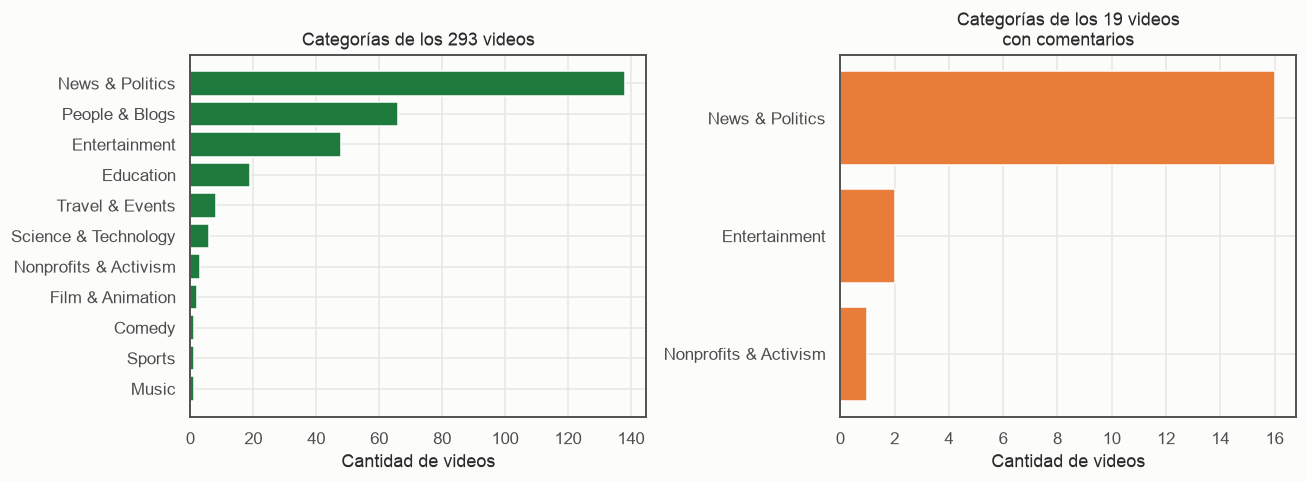

News & Politics es el 47% de todos los videos, pero el 84% de los videos que sí recibieron comentarios.


In [26]:
# Categorías de YouTube: todas las 293 vs. solo las de los 19 videos comentados
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cat_todas = videos_clean['category'].value_counts()
axes[0].barh(cat_todas.index[::-1], cat_todas.values[::-1], color=COLOR_VERDE_OSCURO)
axes[0].set_title('Categorías de los 293 videos')
axes[0].set_xlabel('Cantidad de videos')

cat_comentados = comentarios_por_video['category'].value_counts()
axes[1].barh(cat_comentados.index[::-1], cat_comentados.values[::-1], color=COLOR_NARANJA_OSCURO)
axes[1].set_title('Categorías de los 19 videos\ncon comentarios')
axes[1].set_xlabel('Cantidad de videos')

plt.tight_layout()
plt.show()

print('News & Politics es el', f"{cat_todas['News & Politics']/len(videos_clean):.0%}",
      'de todos los videos, pero el',
      f"{cat_comentados.get('News & Politics', 0)/len(comentarios_por_video):.0%}",
      'de los videos que sí recibieron comentarios.')

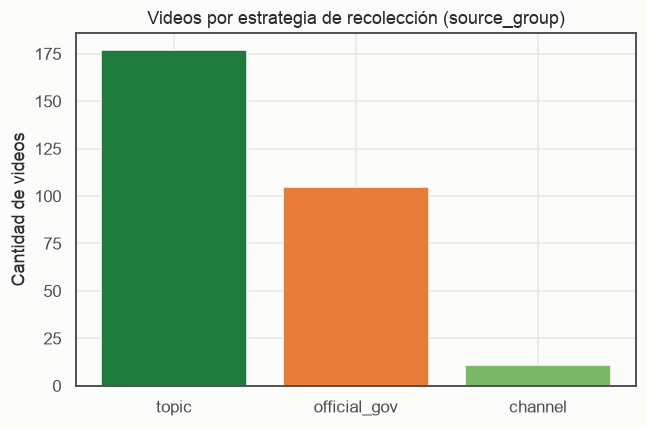

Top 10 consultas de búsqueda (source_query) con más videos encontrados:
source_query
Municipalidad de Guatemala                20
@GobiernodelaRepublicadeGuatema           18
Gobierno de Guatemala                     18
@GobiernodeGuatemala                      17
guatemala noticias                        16
@MunicipalidaddeGuatemala-1551            16
Ministerio de Comunicaciones Guatemala    16
Conred Guatemala                          15
Gobierno de la República de Guatemala     15
PMT Guatemala                             15
Name: count, dtype: int64


In [27]:
# Consultas de búsqueda (cómo se recolectó cada video)
fig, ax = plt.subplots(figsize=(6, 4))
sg = videos_clean['source_group'].value_counts()
ax.bar(sg.index, sg.values, color=[COLOR_VERDE_OSCURO, COLOR_NARANJA_OSCURO, COLOR_VERDE_CLARO])
ax.set_title('Videos por estrategia de recolección (source_group)')
ax.set_ylabel('Cantidad de videos')
plt.tight_layout()
plt.show()

print('Top 10 consultas de búsqueda (source_query) con más videos encontrados:')
print(videos_clean['source_query'].value_counts().head(10))

In [28]:
# Hashtags, menciones, URLs y emojis dentro de los comentarios (extraídos en la sección 2.6)
todos_los_hashtags = [h for lista in comments_clean['hashtags_encontrados'] for h in lista]
print('Comentarios con al menos un hashtag:', (comments_clean['hashtags_encontrados'].str.len() > 0).sum(), 'de', len(comments_clean))
print('Hashtags encontrados en total:', len(todos_los_hashtags), '->', todos_los_hashtags)
print()
print('Comentarios con al menos una mención (@usuario):', (comments_clean['menciones_encontradas'].str.len() > 0).sum())
print('Comentarios con al menos un URL:', comments_clean['tiene_url'].sum())
print('Comentarios con al menos un emoji:', (comments_clean['num_emojis'] > 0).sum(),
      f'({(comments_clean["num_emojis"] > 0).mean():.1%})')

Comentarios con al menos un hashtag: 1 de 406
Hashtags encontrados en total: 1 -> ['ineptobran']

Comentarios con al menos una mención (@usuario): 5
Comentarios con al menos un URL: 1
Comentarios con al menos un emoji: 61 (15.0%)


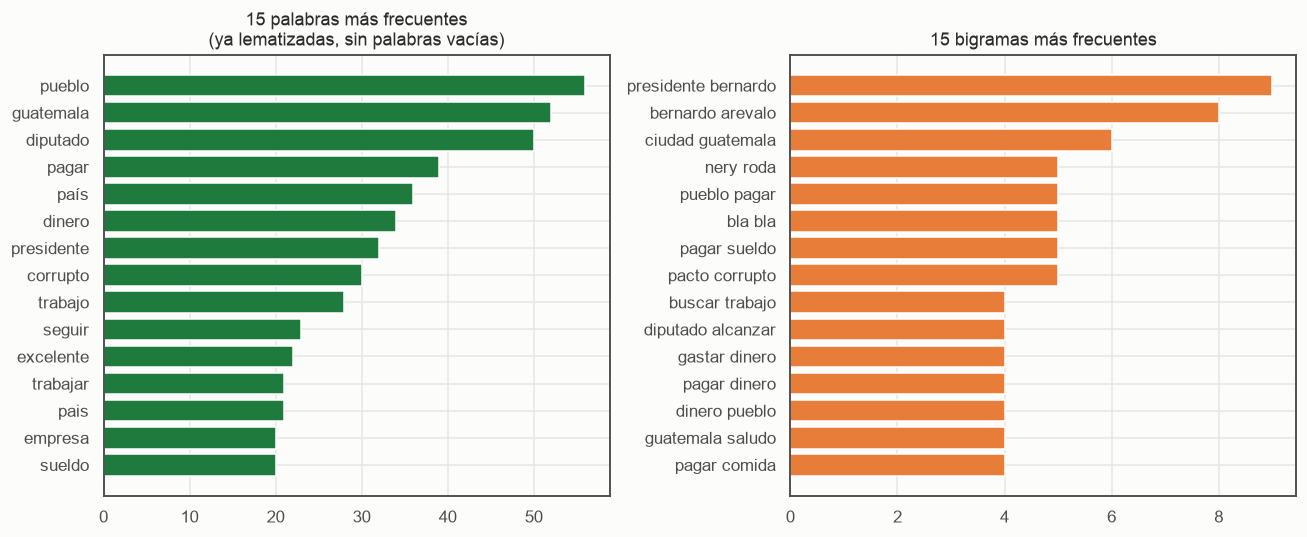

In [29]:
from collections import Counter

tokens_validos = comments_clean['tokens_limpios'].apply(lambda lst: [t for t in lst if len(t) > 2])

conteo_palabras = Counter(t for lista in tokens_validos for t in lista)
palabras_frecuentes = pd.Series(dict(conteo_palabras.most_common(15)))

bigramas = Counter()
for lista in tokens_validos:
    bigramas.update(zip(lista, lista[1:]))
bigramas_frecuentes = pd.Series({' '.join(par): n for par, n in bigramas.most_common(15)})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(palabras_frecuentes.index[::-1], palabras_frecuentes.values[::-1], color=COLOR_VERDE_OSCURO)
axes[0].set_title('15 palabras más frecuentes\n(ya lematizadas, sin palabras vacías)')

axes[1].barh(bigramas_frecuentes.index[::-1], bigramas_frecuentes.values[::-1], color=COLOR_NARANJA_OSCURO)
axes[1].set_title('15 bigramas más frecuentes')

plt.tight_layout()
plt.show()

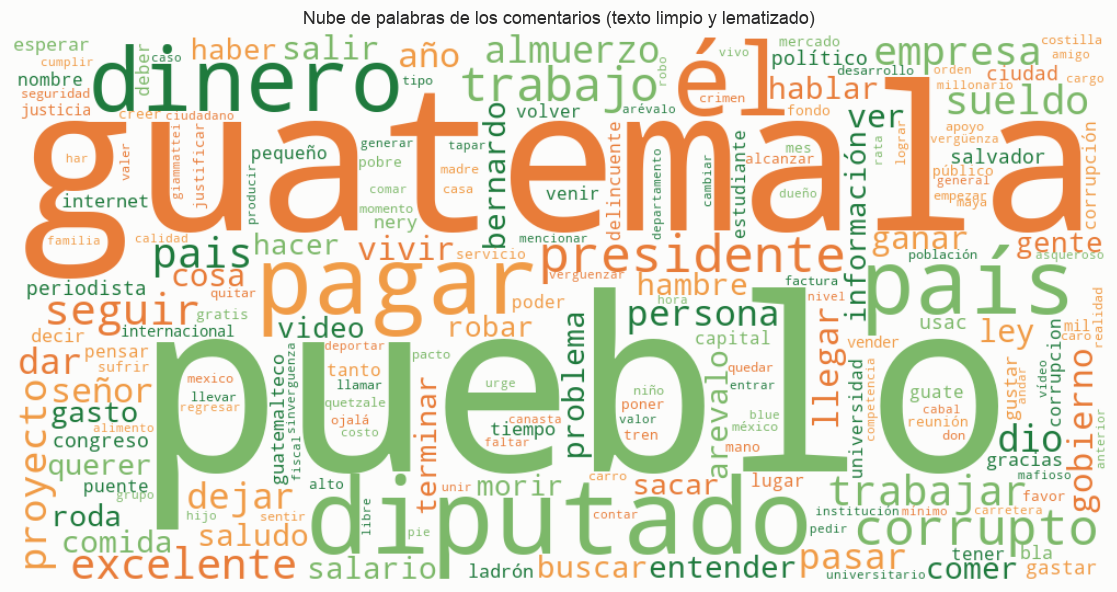

In [30]:
from wordcloud import WordCloud
import random

# Nube de palabras (complementaria a las gráficas de frecuencia de arriba, no las reemplaza)
def colores_lab(*args, **kwargs):
    return random.choice(PALETA_CATEGORICA)

texto_para_nube = ' '.join(t for lista in tokens_validos for t in lista)
nube = WordCloud(width=1000, height=500, background_color='#fcfcfb',
                  color_func=colores_lab, collocations=False).generate(texto_para_nube)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.imshow(nube, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras de los comentarios (texto limpio y lematizado)')
plt.tight_layout()
plt.show()

Los hashtags prácticamente no se usan en los comentarios (solo apareció uno en los 406 registros); los emojis sí son comunes (15% de los comentarios trae al menos uno), mientras que menciones y URLs son casi inexistentes. En cuanto al vocabulario, las palabras y bigramas más frecuentes ("diputado", "pagar", "presidente", "sueldo", "presidente bernardo", "pacto corrupto") muestran que la conversación gira sobre todo en torno a política, dinero público y críticas al gobierno, algo consistente con que el video más comentado sea justamente sobre los sueldos de los diputados.

### 3.2 Concentración de la participación

Ya vimos que la participación no se reparte parejo entre los 293 videos. Ahora medimos qué tan concentrada está entre los videos y canales que sí recibieron comentarios.

El video más comentado concentra el 39.7% de todos los comentarios.
Los 5 videos más comentados concentran el 75.4% de todos los comentarios.

Canales que reciben al menos 1 comentario: 8 de 97 canales totales.
Los 5 canales más comentados concentran el 96.1% de todos los comentarios:
channel_id
Quorum                                   256
Gobierno de la República de Guatemala     70
Noticias Telemundo                        25
Municipalidad de Guatemala                25
Noti7                                     14
dtype: int64



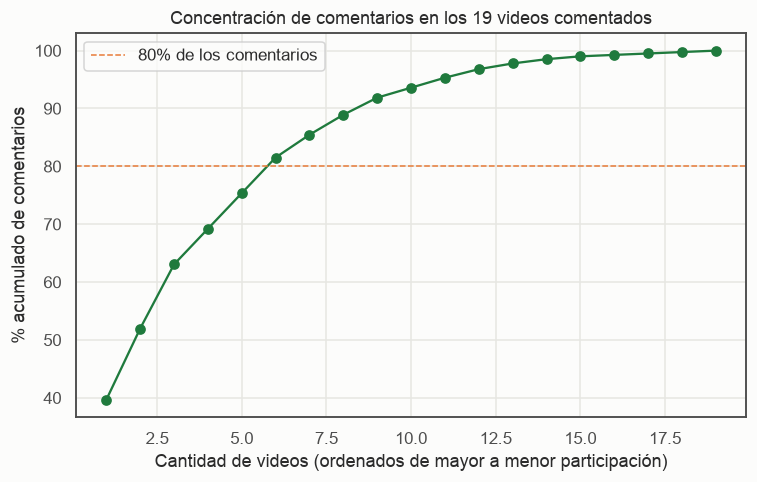

In [31]:
total_comentarios = len(comments_clean)

com_por_video = comments_clean.groupby('video_id').size().sort_values(ascending=False)
com_por_canal = comments_clean.groupby('channel_id').size().sort_values(ascending=False)

print(f'El video más comentado concentra el {com_por_video.iloc[0]/total_comentarios:.1%} de todos los comentarios.')
print(f'Los 5 videos más comentados concentran el {com_por_video.head(5).sum()/total_comentarios:.1%} de todos los comentarios.')
print()
print(f'Canales que reciben al menos 1 comentario: {comments_clean["channel_id"].nunique()} de {videos_clean["channel_id"].nunique()} canales totales.')
print(f'Los 5 canales más comentados concentran el {com_por_canal.head(5).sum()/total_comentarios:.1%} de todos los comentarios:')
nombre_canal = videos_clean.drop_duplicates('channel_id').set_index('channel_id')['channel_name']
print((com_por_canal.head(5).rename(nombre_canal)))
print()

fig, ax = plt.subplots(figsize=(7, 4.5))
acumulado = com_por_video.cumsum() / total_comentarios * 100
ax.plot(range(1, len(acumulado) + 1), acumulado.values, marker='o', color=COLOR_VERDE_OSCURO)
ax.axhline(80, color=COLOR_NARANJA_OSCURO, linestyle='--', linewidth=1, label='80% de los comentarios')
ax.set_xlabel('Cantidad de videos (ordenados de mayor a menor participación)')
ax.set_ylabel('% acumulado de comentarios')
ax.set_title('Concentración de comentarios en los 19 videos comentados')
ax.legend()
plt.tight_layout()
plt.show()

La participación está muy concentrada: solo 8 de los 97 canales reciben algún comentario, y apenas 5 canales concentran el 96% de todos los comentarios — con Quorum solo ya representando el 63%. A nivel de video, un solo video acumula el 40% de todos los comentarios del conjunto de datos, y con solo 5 videos ya se llega al 75%. Esta concentración importa para lo que viene: cualquier red que construyamos con estos datos va a estar dominada por lo que pasó alrededor de un puñado de videos y canales, no por una muestra representativa de todo YouTube Guatemala.

### 3.3 Popularidad (vistas) vs. participación (comentarios)

Comparamos las vistas de un video contra su cantidad de comentarios, solo para los 19 videos que efectivamente tienen comentarios (para el resto no hay con qué comparar).

Correlación entre vistas y cantidad de comentarios (19 videos): 0.07
(cercano a 0 = casi no hay relación lineal entre ambas cosas)



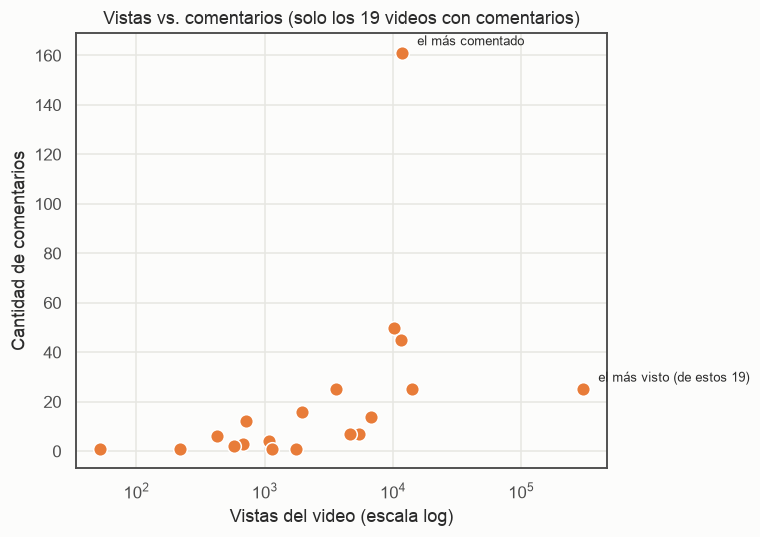

In [32]:
correlacion = comentarios_por_video[['view_count', 'n_comentarios']].corr().iloc[0, 1]
print(f'Correlación entre vistas y cantidad de comentarios (19 videos): {correlacion:.2f}')
print('(cercano a 0 = casi no hay relación lineal entre ambas cosas)')
print()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(comentarios_por_video['view_count'], comentarios_por_video['n_comentarios'],
           s=80, color=COLOR_NARANJA_OSCURO, edgecolor='white', linewidth=1, zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Vistas del video (escala log)')
ax.set_ylabel('Cantidad de comentarios')
ax.set_title('Vistas vs. comentarios (solo los 19 videos con comentarios)')

# Etiquetar el video más comentado y el más visto (entre estos 19) para orientar la lectura
video_mas_comentado = comentarios_por_video.iloc[0]
ax.annotate('el más comentado', (video_mas_comentado['view_count'], video_mas_comentado['n_comentarios']),
            xytext=(10, 5), textcoords='offset points', fontsize=8.5)
video_mas_visto = comentarios_por_video.loc[comentarios_por_video['view_count'].idxmax()]
ax.annotate('el más visto (de estos 19)', (video_mas_visto['view_count'], video_mas_visto['n_comentarios']),
            xytext=(10, 5), textcoords='offset points', fontsize=8.5)

plt.tight_layout()
plt.show()

La correlación es prácticamente nula (0.07): el video más comentado ("Qué rico come tu diputado", 11,775 vistas) no es ni de cerca el más visto. El video con más vistas entre los 19 que sí tienen comentarios ("Plan 2032 Ciudad de Guatemala", más de 300,000 vistas) recibió solo 25 comentarios — y eso sin contar que, de los 293 videos totales, hay varios con muchas más vistas todavía (hasta más de 8 millones) que simplemente no tienen ningún comentario recolectado. Es decir, en esta muestra, ver mucho un video no implica comentar mucho, y viceversa.

Ambas cifras tienen límites que hay que tener presentes: view_count es una sola foto tomada en el momento de la recolección (un video puede seguir sumando vistas después), y el conteo de comentarios depende de qué videos fueron elegidos para recolectar comentarios — no de cuántos comentarios tiene el video en realidad en YouTube. Con solo 19 videos con comentarios, cualquier conclusión sobre esta relación es más una observación puntual que un patrón generalizable.

### 3.4 Visualizaciones

Las gráficas de esta sección (barras de canales y videos, histogramas de vistas y respuestas, categorías, palabras y bigramas, el gráfico de concentración acumulada, el dispersión de vistas vs. comentarios y la nube de palabras) cubren este punto: la nube de palabras se incluyó como complemento visual, no como reemplazo de las comparaciones cuantitativas.

In [33]:
# Evidencia extra para 3.5: ¿hay autores que comentaron en más de un video? (audiencia compartida)
videos_por_autor = comments_clean.groupby('author_channel_id')['video_id'].nunique().sort_values(ascending=False)
autores_multivideo = videos_por_autor[videos_por_autor > 1]
print(f'Autores que comentaron en más de 1 video: {len(autores_multivideo)} de {comments_clean["author_channel_id"].nunique()} '
      f'({len(autores_multivideo)/comments_clean["author_channel_id"].nunique():.1%})')
print()

filas = []
for autor, n_videos in autores_multivideo.items():
    vids = comments_clean.loc[comments_clean['author_channel_id'] == autor, 'video_id'].unique()
    canales = videos_clean.loc[videos_clean['video_id'].isin(vids), 'channel_name'].unique()
    filas.append({'autor': comments_clean.loc[comments_clean['author_channel_id']==autor, 'author_name'].iloc[0],
                   'n_videos': n_videos, 'canales_distintos': len(canales), 'canales': ', '.join(canales)})
tabla_puentes = pd.DataFrame(filas).sort_values(['canales_distintos', 'n_videos'], ascending=False)
tabla_puentes

Autores que comentaron en más de 1 video: 9 de 332 (2.7%)



,autor,n_videos,canales_distintos,canales
3,@virgiliogarcia3039,2,2,"Gobierno de la República de Guatemala, Quorum"
5,@moisesvaldez4043,2,2,"PrensaLibreOficial, Quorum"
6,@MarcosCarillo-b1r,2,2,"TN23 Guatemala, Quorum"
7,@franciscoflores3120,2,2,"Noti7, Gobierno de la República de Guatemala"
0,@hashojea7348,3,1,Quorum
1,@inge_vergueta,3,1,Quorum
2,@Alejandro00710,2,1,Quorum
4,@josegil3813,2,1,Gobierno de la República de Guatemala
8,@Jel.Awesh.M,2,1,Quorum


### 3.5 Preguntas obligatorias

**¿Qué videos y canales concentran la mayor participación observada?**
El video "Qué rico come tu diputado" (canal Quorum) concentra el 40% de todos los comentarios; junto con "La cooptación de Walter Mazariegos en la USAC" (también Quorum), suman cerca de la mitad del total. A nivel de canal, Quorum por sí solo tiene el 63% de todos los comentarios, y junto con Gobierno de la República de Guatemala, Noticias Telemundo, Municipalidad de Guatemala y Noti7 llegan al 96%.

**¿Existen audiencias compartidas entre videos, canales o temas?**
Sí, aunque de forma limitada: 9 de los 332 autores (2.7%) comentaron en más de un video. La mayoría de esos autores se quedó dentro del mismo canal (varios videos de Quorum), pero varios sí cruzaron de canal — por ejemplo, autores que comentaron tanto en un video de Quorum como en uno de Gobierno de la República de Guatemala, PrensaLibreOficial, TN23 Guatemala o Noti7. Esas coincidencias, aunque pocas, son justamente los puentes que va a mostrar la red de la sección 5.

**¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?**
Los de la tabla de arriba con más de un canal distinto — por ejemplo, los autores que conectan Quorum con Gobierno de la República de Guatemala, o con PrensaLibreOficial, TN23 Guatemala y Noti7. Son pocos, pero son los únicos que evitan que la red de canales quede totalmente fragmentada en islas separadas (esto se retoma con medidas formales en las secciones 6 y 8).

**¿Qué temas y sentimientos caracterizan a las principales comunidades de participación?**
Con la evidencia de palabras y bigramas de esta sección, el tema dominante es político-económico: sueldos de diputados, corrupción, dinero público, y menciones directas al presidente Bernardo Arévalo. El sentimiento como tal se mide formalmente en la sección 9, pero el vocabulario ya sugiere un tono mayormente crítico/negativo hacia figuras de gobierno, con la notable excepción del video sobre la Ciudad de Guatemala, donde los comentarios más "likeados" son mensajes nostálgicos y positivos de guatemaltecos en el extranjero.

**¿La visibilidad medida mediante visualizaciones coincide con la participación observada?**
No. La correlación entre vistas y comentarios (para los 19 videos con comentarios) es prácticamente nula (0.07). El video más visto de esa muestra no es el más comentado, y viceversa — más vistas no implica más comentarios en estos datos.

**¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura de los datos?**
Casi todas. Solo 19 de 293 videos tienen comentarios, y esos 19 no son una muestra al azar: parecen elegidos por relevancia temática, no por popularidad. Por eso no se puede concluir nada sobre "qué tan comentado está YouTube Guatemala en general", solo sobre estos 19 videos puntuales. Los 274 videos sin comentarios en los datos no necesariamente carecen de comentarios reales en YouTube — solo no fueron recolectados.

### 3.6 Preguntas adicionales

**Pregunta 1: ¿los comentarios con más "me gusta" también reciben más respuestas, o son cosas independientes?**

Correlación entre me gusta y respuestas: 0.54


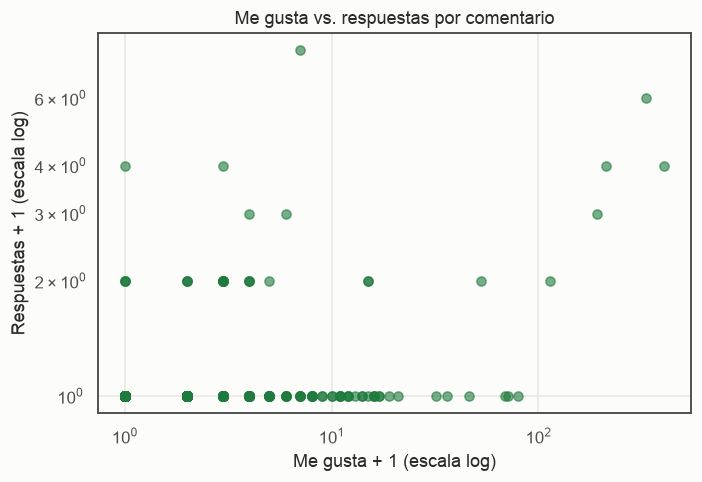

In [34]:
corr_like_reply = comments_clean[['like_count', 'reply_count']].corr().iloc[0, 1]
print(f'Correlación entre me gusta y respuestas: {corr_like_reply:.2f}')

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(comments_clean['like_count'] + 1, comments_clean['reply_count'] + 1,
           alpha=0.6, color=COLOR_VERDE_OSCURO)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Me gusta + 1 (escala log)')
ax.set_ylabel('Respuestas + 1 (escala log)')
ax.set_title('Me gusta vs. respuestas por comentario')
plt.tight_layout()
plt.show()

Hay una relación moderada (0.54): los comentarios con más me gusta tienden a recibir más respuestas también. Tiene sentido — un comentario que mucha gente aprueba también es más probable que genere reacciones de otros usuarios. No es una relación perfecta, pero ambas métricas se mueven en la misma dirección más de lo que se mueven por separado.

**Pregunta 2: ¿los videos institucionales del gobierno (source_group = official_gov) generan comentarios, a pesar de ser más de un tercio de todos los videos recolectados?**

In [35]:
print('Videos por source_group (los 293):')
print(videos_clean['source_group'].value_counts())
print()
print('source_group de los 19 videos que sí tienen comentarios:')
print(comentarios_por_video.merge(videos_clean[['video_id', 'source_group']], on='video_id')['source_group'].value_counts())

Videos por source_group (los 293):
source_group
topic           177
official_gov    105
channel          11
Name: count, dtype: int64

source_group de los 19 videos que sí tienen comentarios:
source_group
topic      12
channel     7
Name: count, dtype: int64


No, ninguno. El 36% de los videos recolectados (105 de 293) vienen de fuentes institucionales de gobierno, pero ninguno de los 19 videos con comentarios pertenece a ese grupo — todos vienen de las categorías "topic" o "channel". Esto puede deberse a que los comentarios de YouTube suelen estar deshabilitados o muy limitados en videos de canales gubernamentales, o simplemente a que la recolección de comentarios no incluyó esos videos. En cualquier caso, no podemos afirmar que el contenido institucional "no genera conversación" — solo que, en esta muestra, no aparece ninguno con comentarios capturados.

**Pregunta 3: entre los comentarios que sí tienen emojis, ¿se concentran en el video más comentado o están repartidos entre varios videos?**

In [36]:
emojis_por_video = comments_clean.groupby('video_id').agg(
    n_comentarios=('comment_id', 'nunique'),
    n_con_emoji=('num_emojis', lambda x: (x > 0).sum()),
)
emojis_por_video['pct_con_emoji'] = (emojis_por_video['n_con_emoji'] / emojis_por_video['n_comentarios'] * 100).round(1)
emojis_por_video = emojis_por_video.merge(videos_clean[['video_id', 'title']], on='video_id').sort_values('n_con_emoji', ascending=False)
emojis_por_video[['title', 'n_comentarios', 'n_con_emoji', 'pct_con_emoji']].head(8)

,title,n_comentarios,n_con_emoji,pct_con_emoji
2,Inician los trabajos de recuperación del Puent...,45,12,26.7
14,Qué rico come tu diputado,161,11,6.8
12,La cooptación de Walter Mazariegos en la USAC,50,9,18.0
4,EE.UU. envía a mexicanos deportados a Guatemal...,25,7,28.0
13,Plan 2032 Ciudad de Guatemala,25,6,24.0
5,Conferencia de Prensa del Gobierno de Guatemal...,25,5,20.0
0,Capturan a presuntos delincuentes disfrazados ...,14,3,21.4
15,Internet: escoger el menos malo,12,2,16.7


Los comentarios con emoji están repartidos entre varios videos, no concentrados en el más comentado. De hecho, el video más comentado ("Qué rico come tu diputado", 161 comentarios) tiene la proporción de emojis más baja de la lista (6.8%), mientras que otros videos con muchos menos comentarios llegan hasta 26-28%. Una lectura posible es que el video con más comentarios generó sobre todo debate político escrito (texto argumentativo), mientras que videos con menos comentarios recibieron más reacciones cortas y emocionales.

## 4. Construcción de la red bipartita autor-video

### 4.1-4.2 Definición de la red

Vamos a representar la participación como una red de dos tipos de nodos: autores y videos. Un nodo autor se conecta con un nodo video cuando ese autor escribió al menos un comentario en ese video. El peso de la conexión es cuántos comentarios escribió ese autor específico en ese video específico (no cuántos comentarios tiene el video en total).

Como red bipartita, no hay conexiones autor-autor ni video-video en este paso — esas se construyen aparte en la sección 5 (proyecciones).

In [37]:
import networkx as nx

# Aristas: cada par (autor, video) con el número de comentarios de ese autor en ese video
aristas_autor_video = (
    comments_clean.groupby(['author_channel_id', 'video_id'])
    .size()
    .reset_index(name='peso')
)

# Atributos por video (para los nodos de tipo video)
atributos_video = comentarios_por_video.set_index('video_id')[
    ['title', 'channel_name', 'category', 'view_count', 'n_comentarios', 'n_autores']
]

# Atributos por autor (para los nodos de tipo autor)
atributos_autor = comments_clean.groupby('author_channel_id').agg(
    author_name=('author_name', 'first'),
    n_videos=('video_id', 'nunique'),
    n_comentarios=('comment_id', 'nunique'),
)

B = nx.Graph()

for video_id, fila in atributos_video.iterrows():
    B.add_node(video_id, tipo='video', titulo=fila['title'], canal=fila['channel_name'],
               categoria=fila['category'], vistas=int(fila['view_count']),
               n_autores=int(fila['n_autores']), n_comentarios_video=int(fila['n_comentarios']))

for author_id, fila in atributos_autor.iterrows():
    B.add_node(author_id, tipo='autor', nombre=fila['author_name'],
               n_videos=int(fila['n_videos']), n_comentarios_autor=int(fila['n_comentarios']))

for _, fila in aristas_autor_video.iterrows():
    B.add_edge(fila['author_channel_id'], fila['video_id'], weight=int(fila['peso']))

print('Nodos totales:', B.number_of_nodes(), '(',
      sum(1 for _, d in B.nodes(data=True) if d['tipo'] == 'video'), 'videos +',
      sum(1 for _, d in B.nodes(data=True) if d['tipo'] == 'autor'), 'autores )')
print('Aristas totales:', B.number_of_edges())
print('Es bipartita:', nx.is_bipartite(B))


Nodos totales: 351 ( 19 videos + 332 autores )
Aristas totales: 343
Es bipartita: True


In [38]:
# 4.3 Tabla de nodos y tabla de aristas
tabla_nodos = pd.DataFrame([
    {'node_id': n, **d} for n, d in B.nodes(data=True)
])
tabla_aristas = nx.to_pandas_edgelist(B)

print('Tabla de nodos:', tabla_nodos.shape)
print('Tabla de aristas:', tabla_aristas.shape)
print()
print('Ejemplo de nodos tipo video:')
display(tabla_nodos[tabla_nodos['tipo'] == 'video'].head(3))
print('Ejemplo de nodos tipo autor:')
display(tabla_nodos[tabla_nodos['tipo'] == 'autor'].head(3))
print('Ejemplo de aristas:')
display(tabla_aristas.head(5))


Tabla de nodos: (351, 11)
Tabla de aristas: (343, 3)

Ejemplo de nodos tipo video:


,node_id,tipo,titulo,canal,categoria,vistas,n_autores,n_comentarios_video,nombre,n_videos,n_comentarios_autor
0,n8iP75gIpmw,video,Qué rico come tu diputado,Quorum,News & Politics,11775.0,128.0,161.0,NaN,NaN,NaN
1,j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,Quorum,News & Politics,10156.0,49.0,50.0,NaN,NaN,NaN
2,6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,Entertainment,11670.0,32.0,45.0,NaN,NaN,NaN


Ejemplo de nodos tipo autor:


,node_id,tipo,titulo,canal,categoria,vistas,n_autores,n_comentarios_video,nombre,n_videos,n_comentarios_autor
19,UC-HeUTT6_g-VoiWds2a4H-w,autor,NaN,NaN,NaN,NaN,NaN,NaN,@JorgeMunoz-gd9et,1.0,1.0
20,UC-Iul5tDYH_oiAMXQH-KaaQ,autor,NaN,NaN,NaN,NaN,NaN,NaN,@AlbertoMancilla-p9h,1.0,1.0
21,UC-QOpE7GOxlXcHZ8b7HbQKA,autor,NaN,NaN,NaN,NaN,NaN,NaN,@mariaalexander427,1.0,2.0


Ejemplo de aristas:


,source,target,weight
0,n8iP75gIpmw,UC-hfX8J5JPJ-dfuakzegMLA,1
1,n8iP75gIpmw,UC-jS_kA9w-OmpupXDx156Rg,1
2,n8iP75gIpmw,UC-pNP6RMFuLg_-x7Ah_0kEA,1
3,n8iP75gIpmw,UC1vr9aaMI2crB0NvwFHUeoQ,1
4,n8iP75gIpmw,UC2Y_EHWQKevubk4vOEBBFxw,1


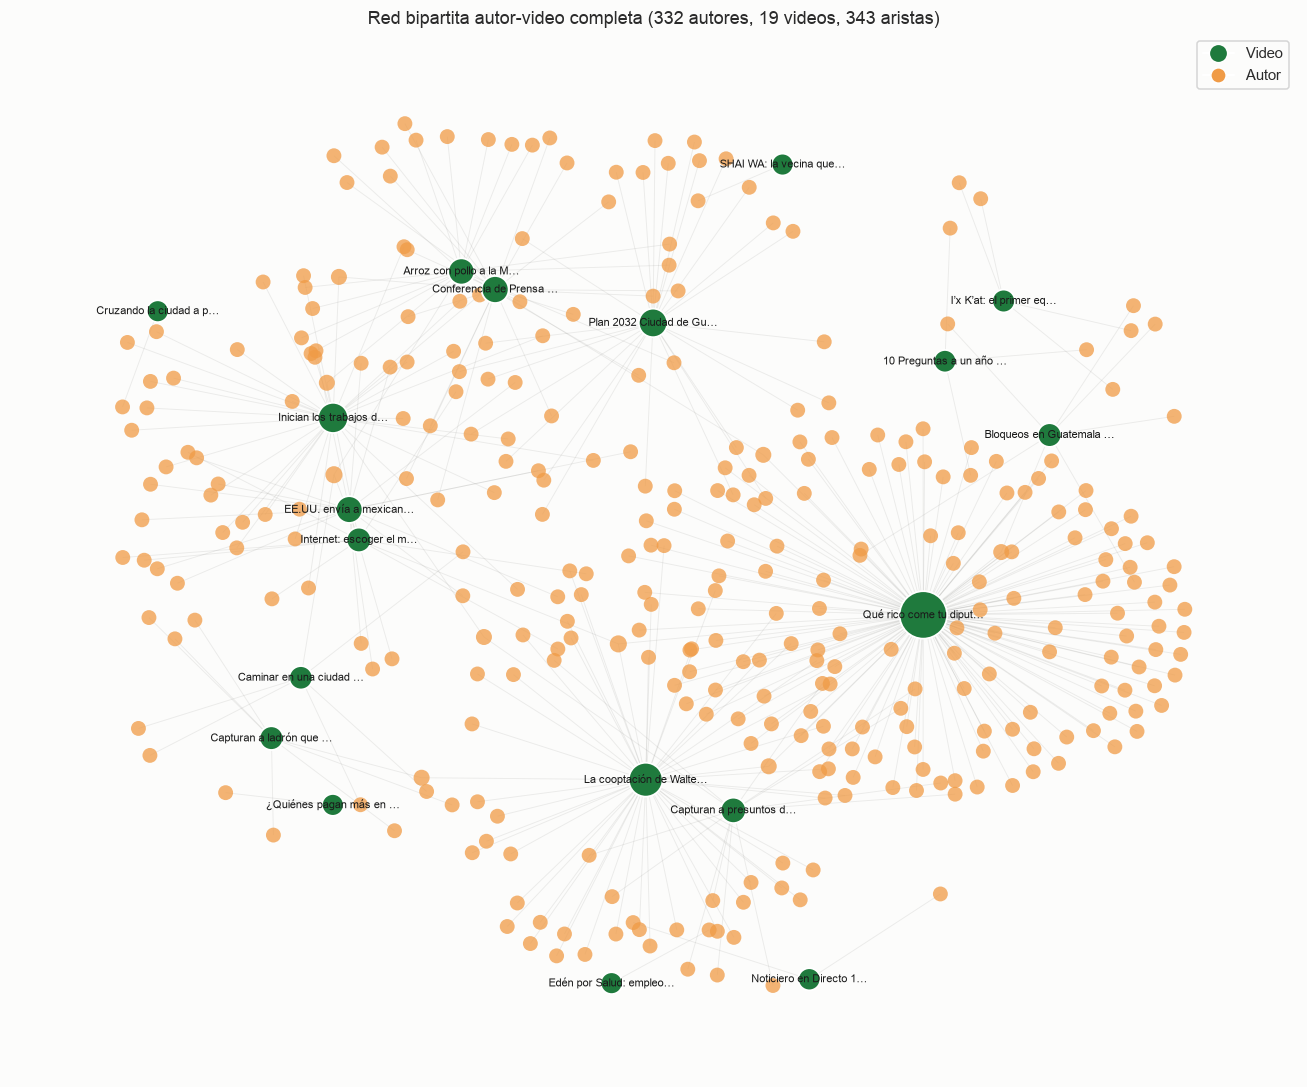

In [39]:
# 4.4 Visualización de la red bipartita completa (los 351 nodos, sin recortar nada)
pos = nx.spring_layout(B, k=0.35, weight='weight', seed=42, iterations=80)

nodos_video = [n for n, d in B.nodes(data=True) if d['tipo'] == 'video']
nodos_autor = [n for n, d in B.nodes(data=True) if d['tipo'] == 'autor']

fig, ax = plt.subplots(figsize=(12, 10))

nx.draw_networkx_edges(B, pos, ax=ax, alpha=0.15, width=0.6, edge_color='#8a8a86')

tam_autor = [80 + 15 * B.nodes[n]['n_videos'] for n in nodos_autor]
nx.draw_networkx_nodes(B, pos, nodelist=nodos_autor, node_size=tam_autor,
                        node_color=COLOR_NARANJA_CLARO, alpha=0.75, linewidths=0, ax=ax)

tam_video = [200 + 6 * B.nodes[n]['n_autores'] for n in nodos_video]
nx.draw_networkx_nodes(B, pos, nodelist=nodos_video, node_size=tam_video,
                        node_color=COLOR_VERDE_OSCURO, edgecolors='white', linewidths=1.2, ax=ax)

etiquetas_video = {n: B.nodes[n]['titulo'][:22] + '…' for n in nodos_video}
nx.draw_networkx_labels(B, pos, labels=etiquetas_video, font_size=7.5, ax=ax)

leyenda = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_VERDE_OSCURO, markersize=12, label='Video'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_NARANJA_CLARO, markersize=10, label='Autor'),
]
ax.legend(handles=leyenda, loc='upper right', fontsize=10)
ax.set_title('Red bipartita autor-video completa (332 autores, 19 videos, 343 aristas)')
ax.axis('off')
plt.tight_layout()
plt.show()


La red se ve dominada por dos nodos verdes grandes (los videos más comentados) rodeados de muchos autores conectados solo a ese nodo, y una nube dispersa de pares aislados alrededor de los videos con pocos comentarios. Esto es exactamente lo que esperábamos después de la sección 3: la participación está muy concentrada en pocos videos, así que la red no se ve como una malla uniforme, sino como un puñado de estrellas grandes con muchas puntas cortas.

### 4.5 Qué significa (y qué no significa) una arista

Una arista entre un autor y un video indica únicamente que ese autor publicó al menos un comentario principal en ese video, y el peso indica cuántos comentarios distintos publicó ahí (40 de las 343 aristas tienen peso mayor a 1, es decir, hubo 40 casos de un mismo autor comentando varias veces en el mismo video).

Lo que una arista no dice:

- No dice que el autor haya visto el video completo, ni que le haya gustado o esté de acuerdo con su contenido, un comentario puede ser una crítica, una burla o un desacuerdo total.
- No conecta al autor con otros autores del mismo video: dos personas que comentaron el mismo video no necesariamente se leyeron entre sí ni conversaron (recordemos que reply_count no identifica quién respondió a quién, así que esta red tampoco lo asume).
- No representa una relación permanente: es una interacción puntual registrada en el momento de la recolección.

En resumen, esta red bipartita muestra dónde se concentró la actividad de comentarios, no relaciones sociales directas entre personas — esas apenas se pueden inferir indirectamente, a través de la coincidencia de haber comentado en el mismo video, que es justo lo que se explora en la sección 5 (proyecciones).

## 5. Proyecciones de la red

In [40]:
from networkx.algorithms import bipartite

# 5.1 Proyeccion autor-autor: dos autores se conectan si comentaron el mismo video
# El peso es el numero de videos que ambos autores tienen en comun
proy_autores = bipartite.weighted_projected_graph(B, nodos_autor)

for autor in proy_autores.nodes():
    proy_autores.nodes[autor].update(B.nodes[autor])

aislados_autores = list(nx.isolates(proy_autores))
pesos_autores = [d['weight'] for _, _, d in proy_autores.edges(data=True)]

print('Proyeccion autor-autor:')
print('Nodos (autores):', proy_autores.number_of_nodes())
print('Aristas (pares de autores con al menos un video en comun):', proy_autores.number_of_edges())
print('Autores aislados (no comparten ningun video con otro autor):', len(aislados_autores))
print('Peso promedio de una arista (videos compartidos):', round(sum(pesos_autores) / len(pesos_autores), 2))
print('Peso maximo de una arista (videos compartidos):', max(pesos_autores))


Proyeccion autor-autor:
Nodos (autores): 332
Aristas (pares de autores con al menos un video en comun): 10732
Autores aislados (no comparten ningun video con otro autor): 4
Peso promedio de una arista (videos compartidos): 1.0
Peso maximo de una arista (videos compartidos): 2


In [41]:
# 5.2 Proyeccion video-video: dos videos se conectan si comparten al menos un autor
# El peso es el numero de autores que ambos videos tienen en comun
proy_videos = bipartite.weighted_projected_graph(B, nodos_video)

for video in proy_videos.nodes():
    proy_videos.nodes[video].update(B.nodes[video])

aislados_videos = list(nx.isolates(proy_videos))
pesos_videos = [d['weight'] for _, _, d in proy_videos.edges(data=True)]
n_pares_posibles = len(nodos_video) * (len(nodos_video) - 1) // 2

print('Proyeccion video-video:')
print('Nodos (videos):', proy_videos.number_of_nodes())
print('Aristas (pares de videos con al menos un autor en comun):', proy_videos.number_of_edges())
print('Aristas posibles entre los', len(nodos_video), 'videos:', n_pares_posibles)
print('Densidad de la proyeccion:', round(nx.density(proy_videos), 3))
print('Videos aislados (no comparten autores con ningun otro video):', len(aislados_videos))
print('Peso promedio de una arista (autores compartidos):', round(sum(pesos_videos) / len(pesos_videos), 2))
print('Peso maximo de una arista (autores compartidos):', max(pesos_videos))


Proyeccion video-video:
Nodos (videos): 19
Aristas (pares de videos con al menos un autor en comun): 11
Aristas posibles entre los 19 videos: 171
Densidad de la proyeccion: 0.064
Videos aislados (no comparten autores con ningun otro video): 9
Peso promedio de una arista (autores compartidos): 1.18
Peso maximo de una arista (autores compartidos): 2


### 5.3 Comparacion de las dos proyecciones

La proyeccion autor-autor queda con 332 nodos y 10732 aristas, una densidad mucho mas alta que cualquier otra red del laboratorio. Esto pasa porque casi todos los autores comentaron en un solo video (solo 9 de 332 comentaron en mas de uno), asi que cada video convierte a todos sus comentaristas en un grupo totalmente conectado entre si. Casi todas las aristas tienen peso 1, es decir esos dos autores comparten exactamente un video, y solo hay 4 autores completamente aislados, que corresponden a videos donde ellos fueron el unico comentarista.

La proyeccion video-video se ve muy distinta. Hay apenas 11 aristas entre los 19 videos con comentarios, sobre 171 pares posibles, con una densidad de 0.064. Nueve de los 19 videos quedan totalmente aislados porque ningun autor que comento ahi volvio a comentar en otro video del conjunto. Las pocas conexiones que existen se explican por esos mismos 9 autores que comentaron en mas de un video.

Cada proyeccion representa un fenomeno distinto. La proyeccion autor-autor muestra coincidencia de audiencia dentro de un mismo video, no una relacion entre personas, que dos autores esten conectados solo dice que comentaron el mismo contenido. La proyeccion video-video muestra si distintos videos atraen al mismo tipo de comentaristas, y en este conjunto de datos esa senal es debil porque la participacion esta muy concentrada por video y casi nadie comento en mas de uno.

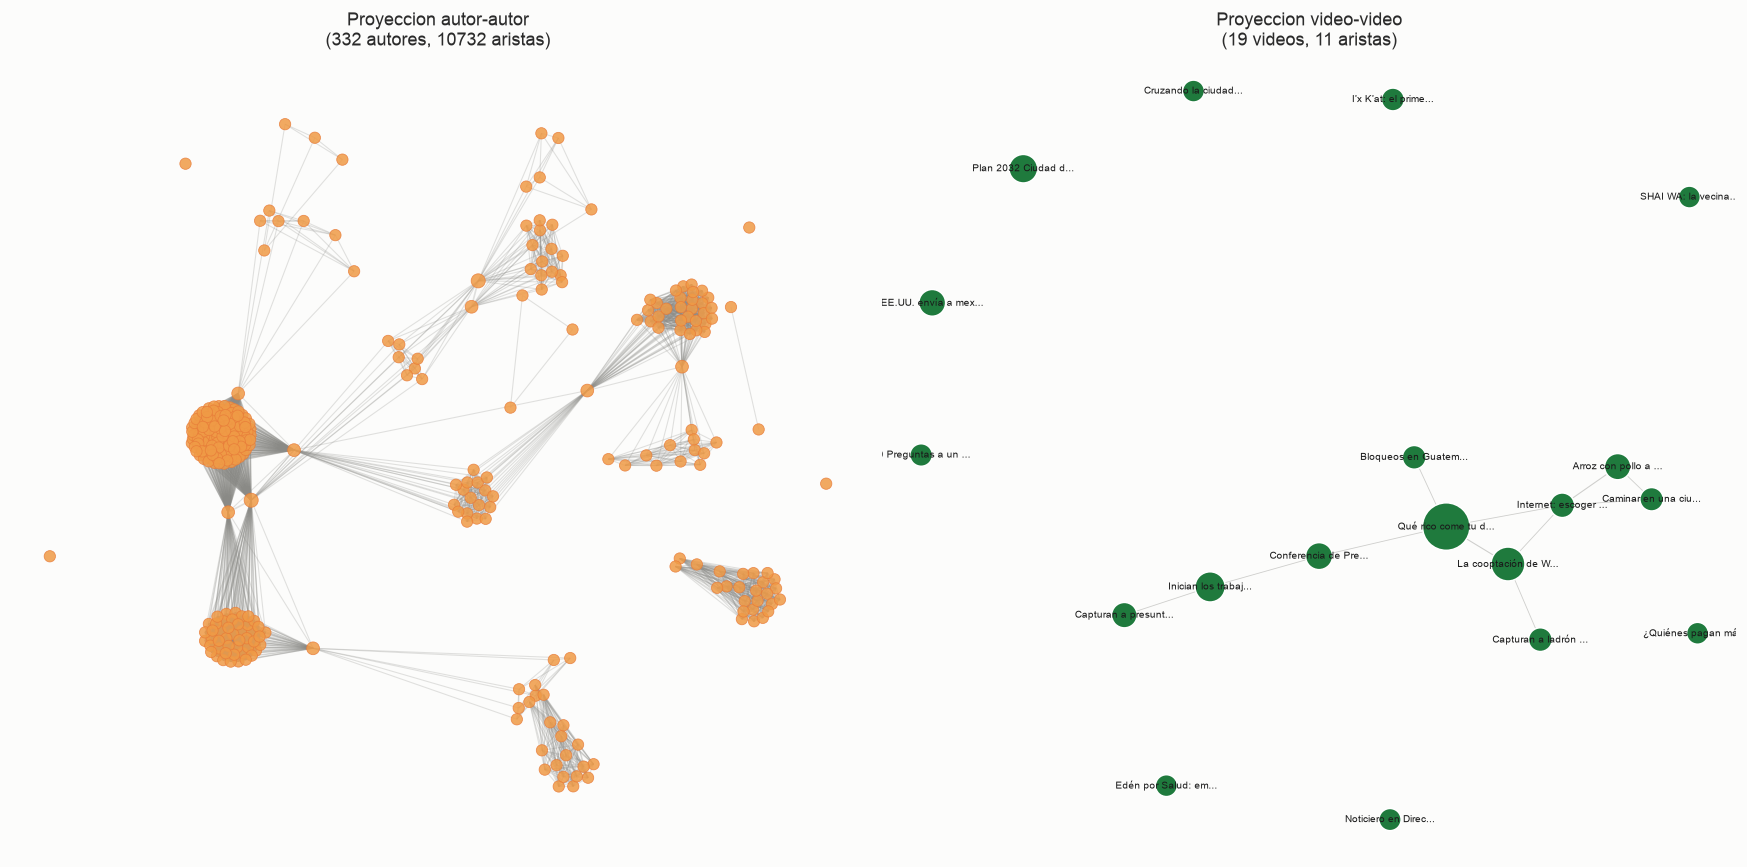

In [42]:
# 5.4 Visualizacion de las dos proyecciones
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Proyeccion autor-autor ---
ax = axes[0]
pos_autores = nx.spring_layout(proy_autores, k=0.4, weight='weight', seed=42, iterations=80)
anchos = [0.3 + 0.4 * d['weight'] for _, _, d in proy_autores.edges(data=True)]
nx.draw_networkx_edges(proy_autores, pos_autores, ax=ax, alpha=0.25, width=anchos, edge_color='#8a8a86')
tam = [40 + 15 * proy_autores.nodes[n]['n_videos'] for n in proy_autores.nodes()]
nx.draw_networkx_nodes(proy_autores, pos_autores, node_size=tam, node_color=COLOR_NARANJA_CLARO,
                        edgecolors=COLOR_NARANJA_OSCURO, linewidths=0.5, alpha=0.85, ax=ax)
ax.set_title(f'Proyeccion autor-autor\n({proy_autores.number_of_nodes()} autores, {proy_autores.number_of_edges()} aristas)')
ax.axis('off')

# --- Proyeccion video-video ---
ax = axes[1]
pos_videos = nx.spring_layout(proy_videos, k=0.6, weight='weight', seed=42, iterations=80)
anchos_v = [0.4 + 0.15 * d['weight'] for _, _, d in proy_videos.edges(data=True)]
nx.draw_networkx_edges(proy_videos, pos_videos, ax=ax, alpha=0.4, width=anchos_v, edge_color='#8a8a86')
tam_v = [200 + 6 * proy_videos.nodes[n]['n_autores'] for n in proy_videos.nodes()]
nx.draw_networkx_nodes(proy_videos, pos_videos, node_size=tam_v, node_color=COLOR_VERDE_OSCURO,
                        edgecolors='white', linewidths=1.0, ax=ax)
etiquetas_v = {n: proy_videos.nodes[n]['titulo'][:18] + '...' for n in proy_videos.nodes()}
nx.draw_networkx_labels(proy_videos, pos_videos, labels=etiquetas_v, font_size=6.5, ax=ax)
ax.set_title(f'Proyeccion video-video\n({proy_videos.number_of_nodes()} videos, {proy_videos.number_of_edges()} aristas)')
ax.axis('off')

plt.tight_layout()
plt.show()


En la proyeccion autor-autor se ven varios grupos compactos y muy densos, cada uno formado por los comentaristas de un mismo video, y casi no hay aristas que conecten un grupo con otro porque casi nadie comento en mas de un video. En la proyeccion video-video la mayoria de los videos aparecen sueltos y solo un grupo pequeno se conecta entre si, lo que confirma que la audiencia compartida entre videos es la excepcion y no la regla en estos datos.